# SDN-MPLS-ML Tech Demonstrator: SDNFlow Dataset EDA Analysis

> El presente documento contiene el analisis integral de tipo EDA sobre el dataset presentado como base para el desarrollo del modelo de Machine Learning de tipo XGBoost para la clasificacion de trafico requerida por el sistema SDN y MPLS implementado. El documento esta distribuido en secciones que permiten explorar tanto las variables consideradas para el entrenamiento final del modelo asi como las variables consideradas dentro de todo el documento, sus interacciones, correlaciones, valores faltantes e incorrectos, distribuciones estadisticas, etc.

1. Desarrollado por: Santiago Arellano [00328370]

## Seccion 1: Definicion de Librerias, variables y funciones auxiliares

### Carga de Librerias
Esta seccion presenta todas las librerias incluidas para el presente notebook. En este caso, las librerias que se usan corresponden en su mayoria a librerias para el manejo de datasets y visualizaciones, asi como librerias de utilidades adicionales usadas por las funciones auxiliares del documento durante el analisis de los datos del dataset.

In [23]:
#! Carga de librerias y modulos

from __future__ import annotations
import platform
import warnings
from datetime import datetime, timezone
import hashlib
import re
from collections.abc import Iterable, Sequence
from itertools import islice
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn import __version__ as sklearn_version

In [24]:
#! Impresiones de ayuda!!
EXECUTION_TIMESTAMP_UTC = datetime.now(timezone.utc)
print(f"Marca de ejecucion UTC: {EXECUTION_TIMESTAMP_UTC.isoformat()}")
print(f"Version de Python: {platform.python_version()}")
print(f"Version de pandas: {pd.__version__}")
print(f"Version de numpy: {np.__version__}")
print(f"Version de matplotlib: {plt.matplotlib.__version__}")
print(f"Version de seaborn: {sns.__version__}")
print(f"Version de scipy: {scipy.__version__}")
print(f"Version de scikit-learn: {sklearn_version}")

Marca de ejecucion UTC: 2026-08-04T16:02:12.009478+00:00
Version de Python: 3.13.13
Version de pandas: 3.0.5
Version de numpy: 2.5.1
Version de matplotlib: 3.11.1
Version de seaborn: 0.13.2
Version de scipy: 1.18.0
Version de scikit-learn: 1.9.0


### Definicion de variables de configuracion del notebook
Esta seccion permite definir las variables de control para la slida y carga de datos, asi como configuraciones de las visualizaciones. En este caso, la configuracion define el archivo de entrada del dataset y la salida de los archivos finales, correspondientes al dataset limpio para entrenamiento, las features por si solas para validacion. Asimismo, las variables de control de todo el documento se registran en esta seccion

In [25]:
#! Configuraciones de variables de estado para la entrada y salida de datos
DATA_PATH = Path("../../../res/data/raw/SDNFlow_Dataset_Normal.csv")
OUTPUT_DIR = Path("../../../res/data/processed")

#! Configuracion de nombres de archivos de salida de datos, trianing dataset y extracciones de varaibles finales para validaciones
TRAINING_OUTPUT_FILENAME = "SDNFlow_Training_Sample_Dataset.csv"
FEATURES_OUTPUT_FILENAME = "SDNFlow_Features_Dataset.csv"

#! Configuraciones de la carga de datos y muestras de datos
CSV_ENCODING = "utf-8"
CSV_SEPARATOR = ","
RANDOM_STATE = 42
SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS = 50_000

#! Configuraciones de comportamiento del notebook
EXPORT_FEATURES_ONLY = True
SAVE_FIGURES = True
TOP_N_PORTS = 20
TOP_N_CATEGORIES = 15
PORT_HEATMAP_TOP_N = 15


### Definiciones de constantes de datos del notebook
Estas constantes se definen alrededor de lo esperado bajo una revision previa del dataset. Especificamente las clases espearadas, las columnas de features y categorias, las configuraciones y requerimientos de aquellas columnas , asi como los puertos esperados para los servicios varios de las aplicaciones

In [26]:
#! Antes de crear el directorio de salida de la informacion aseveramos que la configuracion registrada existe y no es igual a los parametros por defecto
assert DATA_PATH != Path("<USER_TO_DEFINE_INPUT_CSV_PATH>")
assert OUTPUT_DIR != Path("<USER_TO_DEFINE_OUTPUT_DIRECTORY>")

#! Luego aseveramos que la informacion del data path existe y que es un archivo, con lo que sabemos que podemos cargar algo
assert DATA_PATH.exists()
assert DATA_PATH.is_file()

#! Finalmente creamos el directorio de salida si no existe y el de figuras ademas si no existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = OUTPUT_DIR / "figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#! Definimos todas las constantes del documento

"""
Feature columns corresponde a las columnas que pueden ser extraidas de un evento PacketIn en Openflow sin necesidad de seguir todo el flow, es decir,
solo con la inforamcion que llega al sistema inicialmente. La informacion inicial sera usada para la generacion de un record de valor DSCP, asi como de una politica de enrutamiento con reservacion de ancho de banda a seguir
"""
FEATURE_COLUMNS = [
    "eth_type",
    "ip_proto", #Usamos ip proto porque nos permite identificar ipv4 o ipv6
    "src_port",
    "dst_port", #Usamos dst_port porque es mas realista para generar relaciones entre la categoria y el sistema, a excepcion de streaming que no tendria un puerto directo, sino seria un puerto por servicio.
]

"""
Nuestra columna de target siempre es Category yta que contiene la informacion del tipo de trafico que fue identificado en los flows registrados
"""
TARGET_COLUMN = "Category"

"""
Este es el nombre de las clases que se pueden esperar como registradas en el dataset. Estas clases fueron extraidas bajo un analisis preliminar y son las unicas que seran registradas dentro de esta prueba.
"""
EXPECTED_CLASSES = [
    "DNS",
    "FTP",
    "HTTP",
    "ICMP",
    "NTP",
    "SSH",
    "STREAMING",
]

"""
El set de columnas de entrenamiento del dataset corresponde a todas las features + Category, ya que el resto de columnas corresponden a metricas de flujos completados como la cantidad de datos enviados en su totalidad (bytes) o el tiempo total del flujo
"""
TRAINING_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

"""
Esta serie de reglas define los rangos maximos de valores esperados por cada una de las features, los puertos solo permiten 2^16 - 1 valores el protocolo 2^8 - 1 por reglas de los headers IP
"""
FEATURE_RULES = {
    "eth_type": {"min": 0, "max": 65535},
    "ip_proto": {"min": 0, "max": 255},
    "src_port": {"min": 0, "max": 65535},
    "dst_port": {"min": 0, "max": 65535},
}

"""
Este arreglo nos permite traducir el valor del eth_type de IPv4 o IPv6 a una label directa para su registro y visualizacion
"""
ETH_TYPE_LABELS = {
    2048: "IPv4",
    34525: "IPv6",
}
"""
Este arreglo nos permite traducir el valor del ip_proto a una label directa para su registro y visualizacion
"""
IP_PROTO_LABELS = {
    1: "ICMP",
    6: "TCP",
    17: "UDP",
    58: "ICMPv6",
}
"""
Este arreglo muestra informacion base de asociaciones de puertos generalmente registrados a su aplicacion, esto se usa para los well known ports que existen en el dataset
"""
COMMON_PORT_LABELS = {
    20: "FTP-DATA",
    21: "FTP",
    22: "SSH",
    53: "DNS",
    80: "HTTP",
    123: "NTP",
    443: "HTTPS",
}

TEXTUAL_NULL_MARKERS = {"", "null", "none", "nan", "n/a", "?"}

"""
Esquema de columnas usadas para la construccion de reportes automatizados para el dataset
"""
_SCHEMA_COLUMNS = [
    "Columna",
    "dtype",
    "Conteo de No Nulos",
    "Conteo de Nulos",
    "Porcentaje de Nulos",
    "Conteo de Valores Unicos",
    "Porcentaje de Valores Unicos",
    "Muestreo de Valores",
    "Columna con Valor Constante?",
    "Columna Feature?",
    "Columna Target?",
]



#! Configuracion adicional de Pandas y Matplotlib para visualizaciones
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9




### Utilidades del notebook

Las siguientes funciones centralizan validaciones, perfiles de columnas, calculos de asociacion, auditoria de limpieza y exportaciones reproducibles.


In [27]:
def sha256_of_file(path: Path) -> str:
    """Calcula el hash SHA-256 de un archivo.

    Paso a paso:

    1. Convierte la ruta recibida en un objeto ``Path``.
    2. Verifica que la ruta exista.
    3. Verifica que la ruta apunte a un archivo regular.
    4. Abre el archivo en modo binario.
    5. Lee el contenido en bloques de 1 MiB.
    6. Actualiza progresivamente el digest SHA-256.
    7. Devuelve el hash hexadecimal final.

    Args:
        path: Ruta del archivo que se desea procesar.

    Returns:
        Cadena hexadecimal de 64 caracteres con el hash SHA-256.

    Raises:
        FileNotFoundError: Si la ruta no existe.
        IsADirectoryError: Si la ruta no apunta a un archivo.
    """
    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f"No existe el archivo: {file_path}")
    if not file_path.is_file():
        raise IsADirectoryError(f"La ruta no apunta a un archivo: {file_path}")

    #? Aqui usamos un digest, similar a los digest the javax.crypto para generar en base a flujos de bits
    #? la huella del archivo
    digest = hashlib.sha256()

    #? Abrimos el archivo con lectura de bites para registrar chunks de estos y enviarlos directamente al digest
    with file_path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)

    #? Convertimos el hash en un digest hexadecimal legible
    return digest.hexdigest()


def sanitize_values(values: Iterable[Any], limit: int = 5) -> list[str]:
    """Genera una muestra textual segura y compacta de una coleccion.

    Paso a paso:

    1. Valida que ``limit`` no sea negativo.
    2. Toma como maximo ``limit`` elementos del iterable.
    3. Representa los valores nulos como ``"<NA>"``.
    4. Convierte los demas valores a texto.
    5. Elimina espacios externos.
    6. Reemplaza saltos de linea por espacios.
    7. Limita cada representacion a 60 caracteres.
    8. Devuelve la lista resultante.

    Args:
        values: Iterable de valores escalares.
        limit: Numero maximo de valores que se devolveran.

    Returns:
        Lista de cadenas sanitizadas.

    Raises:
        ValueError: Si ``limit`` es negativo.
    """
    if limit < 0:
        raise ValueError("limit no puede ser negativo.")


    resulting_sample_values: list[str] = []

    #? Iteramos sobre el iterable ingrsado bajo el limite usando islice
    for value in islice(values, limit):
        #? Evaluamos si un valor es escalar, si lo es evaluamos si es NA o no esta registrado para filtrarlo, valores de tipo object no se
        #? toman en cuenta en esta seccion
        is_missing = bool(pd.isna(value)) if np.isscalar(value) else False
        if is_missing:
            resulting_sample_values.append("<NA>")
            continue

        #? Limpiamos el texto para registrarlo
        cleaned_text_for_value_storage = str(value).strip()
        cleaned_text_for_value_storage = cleaned_text_for_value_storage.replace("\r", " ").replace("\n", " ")
        resulting_sample_values.append(cleaned_text_for_value_storage[:60])

    return resulting_sample_values


def finalize_figure(name: str | None = None) -> None:
    """Ajusta, guarda opcionalmente, muestra y cierra la figura activa.

    Paso a paso:

    1. Ajusta automaticamente los margenes de la figura.
    2. Comprueba si se deben guardar las figuras.
    3. Crea el directorio de figuras cuando sea necesario.
    4. Limpia el nombre propuesto para usarlo como nombre de archivo.
    5. Guarda la figura como PNG a 180 DPI.
    6. Muestra la figura en el notebook.
    7. Cierra la figura para liberar memoria.

    Args:
        name: Nombre logico del archivo, sin extension.

    Returns:
        ``None``.

    Raises:
        ValueError: Si se solicita guardar y el nombre queda vacio despues de
            eliminar caracteres no seguros.
    """

    plt.tight_layout()

    #? Evaluamos si guardar la figura si esta se considera para ser guardada en base a la configuracion
    #? del archivo en general y si hay un nombre registrado
    if SAVE_FIGURES and name:

        #! Creamos el directorio de figuras si este no se ha creado todavia o no existia en el sistema
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        safe_fig_name_for_storage = re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("._")

        if not safe_fig_name_for_storage:
            raise ValueError(
                "El nombre de la figura no contiene caracteres validos."
            )

        #? Guardamos la figura finalmente
        plt.savefig(
            FIGURES_DIR / f"{safe_fig_name_for_storage}.png",
            dpi=180,
            bbox_inches="tight",
        )

    #? Mostramos la figura y cerramos la figura
    plt.show()
    plt.close()


def random_sample_frame(frame: pd.DataFrame, limit: int) -> pd.DataFrame:
    """Obtiene una muestra reproducible de un ``DataFrame``.

    Paso a paso:

    1. Valida que ``limit`` sea mayor que cero.
    2. Devuelve una copia vacia cuando el conjunto no contiene filas.
    3. Calcula el menor valor entre el numero de filas y el limite.
    4. Extrae una muestra aleatoria usando ``RANDOM_STATE``.
    5. Devuelve un nuevo ``DataFrame``.

    Args:
        frame: ``DataFrame`` que se desea muestrear.
        limit: Numero maximo de filas de la muestra.

    Returns:
        Nuevo ``DataFrame`` con hasta ``limit`` filas.

    Raises:
        ValueError: Si ``limit`` es menor o igual que cero.
    """
    if limit <= 0:
        raise ValueError("limit debe ser mayor que cero.")
    if frame.empty:
        return frame.copy()

    #? Obtenemos la sample size entre el minimo de la longitud del frame o el limite
    #? del usuario
    min_sample_size_corrected = min(len(frame), limit)

    #? Obtenemos una sample con pd.sample usando la cantidad definida en el paso anterior
    #? y el random state configurado del notebook
    return frame.sample(n=min_sample_size_corrected, random_state=RANDOM_STATE)


def normalize_text_series(series: pd.Series) -> pd.Series:
    """Normaliza una serie como texto preservando valores nulos.

    Paso a paso:

    1. Convierte la serie al tipo nullable ``string`` de Pandas.
    2. Elimina espacios al inicio y al final.
    3. Restaura explicitamente los valores ausentes como ``pd.NA``.
    4. Devuelve una nueva serie normalizada.

    Args:
        series: Serie que se desea normalizar.

    Returns:
        Serie de tipo ``string`` con espacios externos eliminados.
    """

    #? Aplicamos un casting de tipo a string a toda la serie
    string_casted_series = series.astype("string")
    normalized_casted_series = string_casted_series.str.strip()

    #? Retornamos la serie, pero mantenemos los nulos originales con pd.NA
    return normalized_casted_series.mask(string_casted_series.isna(), pd.NA)


def normalize_category_series(series: pd.Series) -> pd.Series:
    """Normaliza las etiquetas de la variable objetivo ``Category``.

    Paso a paso:

    1. Normaliza la serie como texto.
    2. Convierte las etiquetas a mayusculas.
    3. Normaliza los marcadores textuales de nulidad.
    4. Detecta las etiquetas que representan valores nulos.
    5. Sustituye esos marcadores por ``pd.NA``.
    6. Devuelve la serie final.

    Args:
        series: Serie con etiquetas de clase.

    Returns:
        Serie nullable normalizada en mayusculas.
    """

    #? Normalizamos las cadenas de una serie categorica para evitar problemas de caqsos duplicados, aplicamos str.upper() dado
    #? que el dataset usado no contiene variaciones entre clases, solo se busca estandarizar
    normalized_categorical_series = normalize_text_series(series).str.upper()

    #? Convertirmos todos los marcadores que conocemos de TEXTUAL_NULL_MARKERS que son marcadores de nulos de texto como NA o <NA> a una representacion
    #? final en minusculas para su correccion si habrian estos casos
    normalized_null_markers_set = {
        str(marker).strip().lower()
        for marker in TEXTUAL_NULL_MARKERS
    }

    #? Intentamos filtrar los marcadores nulos extrayendo una mascara binaria de aquellos valores que esten en el set de marcadores normalizados de nulos
    null_markers_on_cat_series_mask = (
        normalized_categorical_series.str.lower()
        .isin(normalized_null_markers_set)
        .fillna(False)
    )

    #? Retornamos la serie normalizada rellenando aquellos valores de la mascara final con pd.NA
    return normalized_categorical_series.mask(null_markers_on_cat_series_mask, pd.NA)


def is_numeric_like_string(value: Any) -> bool:
    """Indica si un valor es una cadena interpretable como numero finito.

    Paso a paso:

    1. Comprueba que el valor sea una cadena.
    2. Elimina espacios externos.
    3. Rechaza cadenas vacias.
    4. Intenta convertir la cadena a ``float``.
    5. Rechaza valores no convertibles.
    6. Rechaza ``NaN`` e infinitos.
    7. Devuelve el resultado booleano.

    Args:
        value: Valor que se desea evaluar.

    Returns:
        ``True`` si el valor es una cadena numerica finita.
    """
    if not isinstance(value, str):
        return False

    #? Primero normalizamos el valor y si esta vacio retornamos falso, sino intentamos convertir en float y como
    #? el dataset no contiene valores decimales al final, usamos np.isfinite para identificar valores enteros utilizables
    normalized_stripped_value = value.strip()


    if not normalized_stripped_value:
        return False
    try:
        parsed = float(normalized_stripped_value)
    except ValueError:
        return False


    return bool(np.isfinite(parsed))





def build_schema_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Construye una tabla descriptiva del esquema del conjunto de datos.

    Paso a paso:

    1. Crea una lista para almacenar un resumen por columna.
    2. Obtiene el numero total de filas.
    3. Recorre cada columna del ``DataFrame``.
    4. Calcula valores nulos y no nulos.
    5. Calcula cardinalidad y porcentaje de valores unicos.
    6. Obtiene ejemplos sanitizados.
    7. Marca columnas constantes, seleccionadas y objetivo.
    8. Construye un ``DataFrame`` con los resultados.
    9. Ordena las variables seleccionadas y el objetivo primero.
    10. Devuelve la tabla final.

    Args:
        frame: ``DataFrame`` que se desea perfilar.

    Returns:
        ``DataFrame`` con una fila por columna.
    """
    #? Para la reconstruccion de cada una de las filas del nuevo dataframe, guardamos un diccionario que contiene el nombre de la columna como
    #? el indice, seguido de todos los valores de cada punto de analisis
    per_column_analysis_result: list[dict[str, Any]] = []
    total_rows = len(frame)

    #? Recorremos cada columna del dataframe y aplicamos el analisis descrito en la metodologia de la funcion
    for column in frame.columns:
        column_in_analysis_values = frame[column]

        non_null_count = int(column_in_analysis_values.notna().sum())
        null_count = int(column_in_analysis_values.isna().sum())
        unique_count = int(column_in_analysis_values.nunique(dropna=True))
        unique_percentage = (
            unique_count / total_rows * 100.0
            if total_rows
            else 0.0
        )

        #? Almacenamos en la lista de resultados el diccionario con todos los valores calculados por serie
        per_column_analysis_result.append(
            {
                "Columna": column,
                "dtype": str(column_in_analysis_values.dtype),
                "Conteo de No Nulos": non_null_count,
                "Conteo de Nulos": null_count,
                "Porcentaje de Nulos": round(
                    null_count / total_rows * 100.0
                    if total_rows
                    else 0.0,
                    4,
                ),
                "Conteo de Valores Unicos": unique_count,
                "Porcentaje de Valores Unicos": round(unique_percentage, 4),
                "Muestreo de Valores": sanitize_values(
                    column_in_analysis_values.drop_duplicates().tolist()
                ),
                "Columna con Valor Constante?": (
                    unique_count == 1
                    and non_null_count > 0
                ),
                "Columna Feature?": column in FEATURE_COLUMNS,
                "Columna Target?": column == TARGET_COLUMN,
            }
        )

    if not per_column_analysis_result:
        return pd.DataFrame(columns=_SCHEMA_COLUMNS)

    #? Retornamos un nuevo dataframe definido en base a un orden de columnas especifico ordenado por los nombres de feature
    #? -> target y finalmente columnas normales
    return (
        pd.DataFrame(per_column_analysis_result, columns=_SCHEMA_COLUMNS)
        .sort_values(
            ["Columna Feature?", "Columna Target?", "Columna"],
            ascending=[False, False, True],
        )
        .reset_index(drop=True)
    )


def classify_identifier_like(
    column_name: str,
    unique_percentage: float,
    unique_count: int,
    total_rows: int,
) -> bool:
    """Estima si una columna se comporta como identificador.

    Paso a paso:

    1. Normaliza el nombre de la columna.
    2. Compara el nombre con identificadores conocidos.
    3. Comprueba sufijos como ``_id`` o ``_uuid``.
    4. Comprueba si todos o casi todos los valores son unicos.
    5. Devuelve ``True`` si alguna senal es positiva.

    Args:
        column_name: Nombre de la columna.
        unique_percentage: Porcentaje de valores unicos.
        unique_count: Cantidad de valores distintos no nulos.
        total_rows: Numero total de filas del conjunto.

    Returns:
        ``True`` cuando la columna probablemente representa un identificador.
    """
    #? Normalizamos el nombre de la columna para su comparativa con clases esperadas
    lowered_possible_identifier_column_name = column_name.strip().lower()

    """
    Definimos posibles nombres exactos de identificadores, en el dataset sabemos que existe flow_id pero se generaliza la funcion en caso de
    que haya otros identificadores
    """
    possible_exact_coincidences = {
        "id",
        "uuid",
        "hash",
        "flow",
        "flow_id",
        "session",
        "session_id",
        "record_id",
    }

    #? Revisamos si es posible que exista una coincidencia parcial
    possible_matching_keyword_in_identifier_name = (
        lowered_possible_identifier_column_name in possible_exact_coincidences
        or lowered_possible_identifier_column_name.endswith("_id")
        or lowered_possible_identifier_column_name.endswith("_uuid")
        or lowered_possible_identifier_column_name.endswith("_hash")
    )

    #? Revisamos si la columna tiene en su mayoria valores unicos, lo que podria ser identificativo de una columna identificadora.
    #? Nuestra heuristica es del 95%, es decir permitimos solo 5% de repeticion de identificadores que podrian representar registros duplicados
    #? en su totalidad
    possible_total_value_uniqueness_in_identifier_series = (
        total_rows > 0
        and (
            unique_count == total_rows
            or unique_percentage >= 95.0
        )
    )


    return bool(possible_matching_keyword_in_identifier_name or possible_total_value_uniqueness_in_identifier_series)




def feature_validity_report(
    frame: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    dict[str, dict[str, pd.Series]],
]:
    """Evalua la calidad y validez de las variables seleccionadas.

    Paso a paso para cada variable definida en ``FEATURE_RULES``:

    1. Recupera la columna o crea una serie nula si falta.
    2. Convierte la columna a texto nullable.
    3. Identifica nulos reales.
    4. Identifica cadenas vacias.
    5. Identifica marcadores textuales de nulidad.
    6. Identifica booleanos.
    7. Convierte los valores a numeros.
    8. Identifica valores finitos e infinitos.
    9. Identifica cadenas numericas.
    10. Identifica cadenas no numericas.
    11. Identifica conversiones fallidas.
    12. Comprueba limite inferior.
    13. Comprueba limite superior.
    14. Comprueba integralidad.
    15. Construye una mascara de invalidez.
    16. Agrega estadisticas al resumen.
    17. Guarda todas las mascaras en el detalle.
    18. Devuelve resumen, matriz numerica y detalle.

    Args:
        frame: Conjunto de datos con las variables de entrada.

    Returns:
        Tupla con:

        * tabla resumen por variable;
        * ``DataFrame`` numerico;
        * diccionario de mascaras detalladas.
    """
    #? Creamos las estructuras de almacenamiento finales, para los resumenes por variables, y el diccionario de las mascaras aplicadas
    #? a los datos
    per_variable_summary_data_rows: list[dict[str, Any]] = []
    numeric_frame = pd.DataFrame(index=frame.index) #Copia del dataframe original con el indice original que se retorna al caller
    per_variable_mask_data_rows: dict[str, dict[str, pd.Series]] = {}

    null_markers = {
        str(marker).strip().lower()
        for marker in TEXTUAL_NULL_MARKERS
    }

    #? En este caso, analizamos las variables definidas en FEATURE_RULES, que corresponden a las variables numericas de analisis en el dataset dado
    #? que para un analisis PacketIn de Openflow, no podemos analizar las variables generales que el sistema reconoce como bytes_tot, etc. En este caso,
    #? nos centramos en las variables que identifican a un flujo sin necesidad de hacer la evaluacion durante todo el flujo de datos
    for column, bounds in FEATURE_RULES.items():

        per_feature_rule_column_in_analysis_series = (
            frame[column] #Tomamos la columna real si es que tiene datos, si no una serie llena de nulos
            if column in frame.columns
            else pd.Series(
                pd.NA,
                index=frame.index,
                dtype="object",
                name=column,
            )
        )

        #? Convertimos todas las representaciones a texto inicialmente para limpiar espacios extra
        per_feature_series_as_string = per_feature_rule_column_in_analysis_series.astype("string")
        per_feature_series_as_string_stripped = per_feature_series_as_string.str.strip()

        #? Extraemos una mascara binaria de los nulos reales registrados en la columna
        genuine_null_mask = per_feature_rule_column_in_analysis_series.isna()

        #? Extraemos una mascara binaria aplicada con la operacion de bitwise and en base a la mascara binaria de
        #? cuales strings estaban vacias AND NOT(nulos antes)
        empty_string_mask_on_non_null_mask = (
            per_feature_series_as_string_stripped.fillna("").eq("")
            & ~genuine_null_mask
        )

        #? Extraemos una mascara binaria aplicada a aquellos registros que NO son nulos para identificar valores con
        #? texto como NA
        textual_null_mask_on_non_null_mask = (
            per_feature_series_as_string_stripped.str.lower()
            .isin(null_markers)
            .fillna(False)
            & ~genuine_null_mask # Bitwise AND con NOT(null mask)
        )

        #? Identificamos booleanos, que no deben aceptarse como enteros.
        textual_bools_mask_on_non_null_mask = (
            per_feature_rule_column_in_analysis_series.map(
                lambda value: isinstance(
                    value,
                    (bool, np.bool_),
                )
            )
            .fillna(False)
        )


        per_feature_column_numeric_series = pd.to_numeric(per_feature_rule_column_in_analysis_series, errors="coerce")
        numeric_frame[column] = per_feature_column_numeric_series


        #? Convertirmos la serie actual en un arreglo de tipo float para identificar aquellos valores finitos e infinitos
        numeric_array = per_feature_column_numeric_series.to_numpy(
            dtype=float,
            na_value=np.nan,
        )


        finite_mask = pd.Series(
            np.isfinite(numeric_array),
            index=frame.index,
        )

        infinite_mask = pd.Series(
            np.isinf(numeric_array),
            index=frame.index,
        )

        numeric_string_mask = (
            per_feature_rule_column_in_analysis_series.map(is_numeric_like_string)
            .fillna(False)
        )
        non_numeric_string_mask = (
            per_feature_rule_column_in_analysis_series.map(
                lambda value: (
                    isinstance(value, str)
                    and bool(value.strip())
                    and not is_numeric_like_string(value)
                    and value.strip().lower()
                    not in null_markers
                )
            )
            .fillna(False)
        )

        #? Identificamos los valores convertidos a nulo
        converted_to_null = (
            ~genuine_null_mask
            & ~empty_string_mask_on_non_null_mask
            & ~textual_null_mask_on_non_null_mask
            & per_feature_column_numeric_series.isna()
            & ~textual_bools_mask_on_non_null_mask
        )

        negative_mask = (
            finite_mask
            & (per_feature_column_numeric_series < bounds["min"])
        )
        above_range_mask = (
            finite_mask
            & (per_feature_column_numeric_series > bounds["max"])
        )
        non_integral_mask = pd.Series(
            False,
            index=frame.index,
        )
        finite_values = per_feature_column_numeric_series.loc[finite_mask]

        #? Marcamos todos los valores en la mascara de valores no integrales bajo el negativo
        #? de la mascara original de valores finitos
        non_integral_mask.loc[finite_mask] = ~np.isclose(
            np.mod(
                finite_values.to_numpy(dtype=float),
                1.0,
            ),
            0.0,
        )


        #? Extraemos una nueva mascara de todos los valores que fueron aplicados
        invalid_mask = (
            textual_bools_mask_on_non_null_mask
            | non_numeric_string_mask
            | infinite_mask
            | negative_mask
            | above_range_mask
            | non_integral_mask
        ).fillna(False)

        #? Agregamos toda la informacion en una nueva fila a la tabla de resultados
        per_variable_summary_data_rows.append(
            {
                "feature": column,
                "genuine_nulls": int(genuine_null_mask.sum()),
                "empty_strings": int(empty_string_mask_on_non_null_mask.sum()),
                "textual_null_markers": int(
                    textual_null_mask_on_non_null_mask.sum()
                ),
                "numeric_strings": int(
                    numeric_string_mask.sum()
                ),
                "booleans": int(textual_bools_mask_on_non_null_mask.sum()),
                "non_numeric_strings": int(
                    non_numeric_string_mask.sum()
                ),
                "infinite_values": int(
                    infinite_mask.sum()
                ),
                "converted_to_null": int(
                    converted_to_null.sum()
                ),
                "negative_values": int(
                    negative_mask.sum()
                ),
                "above_range_values": int(
                    above_range_mask.sum()
                ),
                "non_integral_values": int(
                    non_integral_mask.sum()
                ),
                "invalid_rows": int(invalid_mask.sum()),
            }
        )

        #? Conservamos todos los resultados y las mascaras aplicadas para poder analizar los objetos aplicados a detalle
        per_variable_mask_data_rows[column] = {
            "raw": per_feature_rule_column_in_analysis_series,
            "numeric": per_feature_column_numeric_series,
            "genuine_null": genuine_null_mask,
            "empty_string": empty_string_mask_on_non_null_mask,
            "textual_null": textual_null_mask_on_non_null_mask,
            "boolean_mask": textual_bools_mask_on_non_null_mask,
            "numeric_string_mask": numeric_string_mask,
            "non_numeric_string_mask": (
                non_numeric_string_mask
            ),
            "infinite_mask": infinite_mask,
            "converted_to_null": converted_to_null,
            "negative_mask": negative_mask,
            "above_range_mask": above_range_mask,
            "non_integral_mask": non_integral_mask,
            "invalid_mask": invalid_mask,
        }

    return (
        pd.DataFrame(per_variable_summary_data_rows),
        numeric_frame,
        per_variable_mask_data_rows,
    )


def port_bucket(series: pd.Series) -> pd.Series:
    """Agrupa puertos TCP o UDP segun rangos administrativos.

    Paso a paso:

    1. Convierte la serie a valores numericos.
    2. Define los limites de los tres rangos de puertos.
    3. Define las etiquetas descriptivas.
    4. Aplica ``pd.cut``.
    5. Devuelve una serie categorica.

    Args:
        series: Serie con numeros de puerto.

    Returns:
        Serie categorica con el mismo indice que la entrada.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    #? Definimos los rangos de los puertos, definiendo explicitamente el limite de los well known, reserved y ephemereal ports
    bins = [
        -0.5,
        1023.5,
        49151.5,
        65535.5,
    ]
    labels = [
        "Well Known Ports ",
        "Registered Ports",
        "Dynamic Ports",
    ]

    #? Retornamos la serie asignada cada valor a una bin especifica con su label correspondiente
    return pd.cut(
        numeric,
        bins=bins,
        labels=labels,
        include_lowest=True,
    )


def describe_numeric_series(
    series: pd.Series,
) -> dict[str, float | int]:
    """Calcula estadisticas descriptivas de una serie numerica.

    Paso a paso:

    1. Convierte valores compatibles a numeros.
    2. Descarta valores no finitos.
    3. Descarta valores nulos.
    4. Devuelve una estructura vacia si no quedan datos.
    5. Calcula conteo, minimo y maximo.
    6. Calcula media y mediana.
    7. Calcula desviacion estandar.
    8. Calcula primer y tercer cuartil.
    9. Calcula asimetria cuando hay datos suficientes.
    10. Calcula curtosis cuando hay datos suficientes.
    11. Devuelve el diccionario final.

    Args:
        series: Serie con valores numericos o convertibles.

    Returns:
        Diccionario de estadisticas descriptivas.
    """
    cleaned = pd.to_numeric(series, errors="coerce")
    cleaned = cleaned[np.isfinite(cleaned)].dropna()

    #? Si no hay valores luego de limpiar los valores de la columna retorna todo vacio
    if cleaned.empty:
        return {
            "count": 0,
            "min": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
        }

    #? Retorna todos los valores calculados en el caso de que si hayan valores
    return {
        "count": int(cleaned.count()),
        "min": float(cleaned.min()),
        "max": float(cleaned.max()),
        "mean": float(cleaned.mean()),
        "median": float(cleaned.median()),
        "std": (
            float(cleaned.std(ddof=1))
            if len(cleaned) > 1
            else 0.0
        ),
        "q1": float(cleaned.quantile(0.25)),
        "q3": float(cleaned.quantile(0.75)),
        "skew": (
            float(cleaned.skew())
            if len(cleaned) > 2
            else np.nan
        ),
        "kurtosis": (
            float(cleaned.kurtosis())
            if len(cleaned) > 3
            else np.nan
        ),
    }


def assert_no_output_overwrite(
    data_path: Path,
    output_paths: Sequence[Path],
) -> None:
    """Impide que una salida sobrescriba el archivo fuente.

    Paso a paso:

    1. Normaliza la ruta del archivo fuente.
    2. Crea un conjunto de rutas de salida ya observadas.
    3. Recorre cada ruta de salida.
    4. Normaliza cada ruta.
    5. Comprueba si coincide con la fuente.
    6. Comprueba si esta repetida.
    7. Registra la ruta como validada.
    8. Finaliza sin retorno cuando todas son seguras.

    Args:
        data_path: Ruta del archivo fuente.
        output_paths: Rutas propuestas para los artefactos.

    Returns:
        ``None``.

    Raises:
        ValueError: Si una salida coincide con la fuente o esta repetida.
    """
    resolved_source = (
        Path(data_path)
        .expanduser()
        .resolve(strict=False)
    )

    resolved_outputs: set[Path] = set()

    # Recorre cada salida propuesta.
    for candidate in output_paths:
        # Normaliza la ruta candidata de la misma forma que la fuente.
        resolved_candidate = (
            Path(candidate)
            .expanduser()
            .resolve(strict=False)
        )

        # Impide que una salida reemplace el archivo de entrada.
        if resolved_candidate == resolved_source:
            raise ValueError(
                f"La salida {candidate} apunta al mismo archivo que la fuente."
            )

        # Impide que dos artefactos compartan exactamente la misma ruta.
        if resolved_candidate in resolved_outputs:
            raise ValueError(
                f"La ruta de salida esta repetida: {candidate}"
            )

        # Marca la ruta como revisada.
        resolved_outputs.add(resolved_candidate)

## Seccion 2: Carga de datos

En esta seccion se valida la ruta de entrada, se carga el CSV con la configuracion declarada y se conserva una copia cruda sin modificaciones.


In [28]:
#! Definimos aserciones de la configuracion actual, es decir, si tenemos una ruta de salida, archivo de datos, y si existen
assert DATA_PATH != Path("<USER_TO_DEFINE_INPUT_CSV_PATH>"), "Debe actualizar DATA_PATH antes de ejecutar la carga."
assert OUTPUT_DIR != Path("<USER_TO_DEFINE_OUTPUT_DIRECTORY>"), "Debe actualizar OUTPUT_DIR antes de ejecutar la exportacion."
assert DATA_PATH.exists(), f"No existe el archivo fuente: {DATA_PATH}"
assert DATA_PATH.is_file(), f"La ruta de entrada no es un archivo: {DATA_PATH}"


#? Definimos las rutas de salidas del dataset de training, y features basadao en la operacion de / concatenacion de paths desde OUTPUTDIR
#? un objeto Path y el nombre del archivo de salida
TRAINING_OUTPUT_PATH = OUTPUT_DIR / TRAINING_OUTPUT_FILENAME
FEATURES_OUTPUT_PATH = OUTPUT_DIR / FEATURES_OUTPUT_FILENAME
assert_no_output_overwrite(DATA_PATH, [TRAINING_OUTPUT_PATH, FEATURES_OUTPUT_PATH])

source_size_bytes = DATA_PATH.stat().st_size
source_sha256 = sha256_of_file(DATA_PATH)

#! Leemos el archivo de datos y lo cargamos dentro del notebook
try:
    df_raw = pd.read_csv(DATA_PATH, encoding=CSV_ENCODING, sep=CSV_SEPARATOR)
except UnicodeDecodeError as exc:
    raise UnicodeDecodeError(exc.encoding, exc.object, exc.start, exc.end, f"Fallo de decodificacion para {DATA_PATH}: {exc.reason}")
except pd.errors.EmptyDataError as exc:
    raise ValueError(f"El CSV esta vacio: {DATA_PATH}") from exc
except pd.errors.ParserError as exc:
    raise ValueError(f"El CSV es invalido o esta mal formado: {DATA_PATH}") from exc

if df_raw.empty:
    raise ValueError("El dataset fuente no contiene filas.")
if pd.Index(df_raw.columns).duplicated().any():
    duplicated_names = pd.Index(df_raw.columns)[pd.Index(df_raw.columns).duplicated()].tolist()
    raise ValueError(f"Se detectaron nombres de columna duplicados: {duplicated_names}")

#! Realizamos una copia de los datos del notebook para su analisis
df = df_raw.copy(deep=True)
source_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)



In [29]:
print(f"Archivo fuente: {DATA_PATH.name}")
print(f"Ruta fuente: {DATA_PATH}")
print(f"Tamano del archivo: {source_size_bytes:,} bytes")
print(f"SHA-256 de la fuente: {source_sha256}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns):,}")
print(f"Memoria aproximada del dataframe: {source_memory_mb:,.2f} MB")


Archivo fuente: SDNFlow_Dataset_Normal.csv
Ruta fuente: ../../../res/data/raw/SDNFlow_Dataset_Normal.csv
Tamano del archivo: 36,914,686 bytes
SHA-256 de la fuente: 9b35c490b2a40e42de4151cfcdeb788be9a3cbf2f0fe8eead6f35f409fc36dfb
Filas: 221,564
Columnas: 39
Memoria aproximada del dataframe: 98.43 MB


In [30]:
display(df.head(10))

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,17532.756490,97.033375,180.687898,12560,112694,0,28368.00000,48686.674830,625,157.000000,0,270.202702,2,2.0,2,0.0,5,5.000000,5,0.000000,113472,7295988,628,6659,628,1,10,0,SSH
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,3788.399072,57.231245,66.194595,7400,24294,0,6123.00000,10491.343150,367,92.500000,0,158.487381,2,2.0,2,0.0,5,5.000000,5,0.000000,26080,24492,381,370,370,2,1,0,SSH
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,460.817007,0.833681,552.750000,32,1180,0,737.00000,524.675773,2,1.333333,0,0.942809,4,4.0,4,0.0,0,0.000000,0,0.000000,28291,3799,385,15,0,3,2,0,ICMP
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,422.515979,205016,44867,11454,36334.95638,2870.840349,103,85.996644,22,4.407512,596,596.0,596,0.0,0,0.000000,0,0.000000,188960322,180776253,157117,153898,30743,60,19,0,STREAMING
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,1347.395418,917632,935885,32828,518629.67790,121204.950600,673,384.912752,29,84.666811,596,596.0,596,0.0,0,0.000000,0,0.000000,188960322,180776253,157117,153898,122654,60,19,0,STREAMING
5,6,2048,192.168.56.201,192.168.56.203,17,48550,1235,590.746,13098,119,22.171966,0.201440,110.067227,952,228,0,44.25000,54.775263,2,0.402027,0,0.497150,2,2.0,2,0.0,5,3.669492,3,0.625111,188960322,180776253,157117,153898,127,60,19,0,STREAMING
6,7,2048,192.168.56.201,192.168.56.203,17,57427,1237,590.742,13098,119,22.172116,0.201442,110.067227,952,228,0,44.25000,54.775263,2,0.402027,0,0.497150,2,2.0,2,0.0,5,3.669492,3,0.625111,188960322,180776253,157117,153898,127,60,19,0,STREAMING
7,8,2048,192.168.56.203,192.168.56.201,6,57310,8080,1.910,1588,11,831.413613,5.759162,144.363636,220,328,328,328.00000,0.000000,3,3.000000,3,0.000000,4,4.0,4,0.0,0,0.000000,0,0.000000,26080,1588,381,11,11,2,1,0,STREAMING
8,9,2048,192.168.56.201,192.168.56.203,6,8080,57310,1.880,2706,11,1439.361702,5.851064,246.000000,220,66,66,66.00000,0.000000,1,1.000000,1,0.000000,4,4.0,4,0.0,0,0.000000,0,0.000000,7182516,7295988,6031,6659,11,9,10,0,STREAMING
9,10,2048,192.168.56.201,192.168.56.203,17,53173,1234,536.328,140782767,104421,262493.785500,194.696156,1348.222743,835368,935885,0,523356.01120,120002.300700,673,388.182156,0,84.062069,536,536.0,536,0.0,0,0.000000,0,0.000000,304475260,304472398,258349,258314,211167,10,9,0,STREAMING


In [31]:
display(df.tail(5))

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
221559,221560,2048,192.168.56.203,200.24.19.252,17,47396,53,0.666,0,0,0.000000,0.000000,0.000000,0,0,0,0.0,0.0,0,0.0,0,0.0,1,1.0,1,0.0,0,0.0,0,0.0,4172,197595,27,1967,5,32,152,0,DNS
221560,221561,2048,192.168.56.203,104.18.134.59,6,43528,443,0.666,1658,13,2489.489489,19.519520,127.538461,260,1658,1658,1658.0,0.0,13,13.0,13,0.0,2,2.0,2,0.0,0,0.0,0,0.0,3496,197595,25,1967,1924,2,152,0,HTTP
221561,221562,2048,192.168.56.203,143.204.23.23,6,45516,443,0.664,210,3,316.265060,4.518072,70.000000,60,210,210,210.0,0.0,3,3.0,3,0.0,2,2.0,2,0.0,0,0.0,0,0.0,210,197595,3,1967,1924,1,152,0,HTTP
221562,221563,2048,192.168.56.203,38.71.2.235,6,44300,443,0.661,0,0,0.000000,0.000000,0.000000,0,0,0,0.0,0.0,0,0.0,0,0.0,1,1.0,1,0.0,0,0.0,0,0.0,0,197595,0,1967,1924,1,152,0,HTTP
221563,221564,2048,192.168.56.203,108.156.78.84,6,33960,443,0.661,198,3,299.546142,4.538578,66.000000,60,198,198,198.0,0.0,3,3.0,3,0.0,2,2.0,2,0.0,0,0.0,0,0.0,198,197595,3,1967,1924,1,152,0,HTTP


In [32]:
display(random_sample_frame(df, min(10, len(df))))

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
142389,142390,2048,192.168.56.203,92.204.54.4,6,39488,443,4.163,480,8,115.301465,1.921691,60.000000,160,480,0,160.000000,226.274170,8,2.666667,0,3.771236,2,2.0,2,0.0,3,3.0,3,0.0,20337,75926,141,372,185,8,34,0,HTTP
130537,130538,2048,200.24.19.252,192.168.56.203,17,53,59240,1.000,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,14308583,0,12055,0,0,58,9,0,DNS
145394,145395,2048,216.200.232.249,192.168.56.203,6,443,55574,0.890,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,147314777,0,124936,0,0,18,1,0,HTTP
148948,148949,2048,192.168.56.203,143.204.23.107,6,53764,443,0.277,144,2,519.855596,7.220217,72.000000,40,0,0,0.000000,0.000000,0,0.000000,0,0.000000,2,2.0,2,0.0,3,3.0,3,0.0,144,19771,2,137,91,1,23,0,HTTP
125825,125826,2048,8.43.72.97,192.168.56.203,6,443,58248,0.964,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,96058077,0,81324,0,0,45,2,0,HTTP
191499,191500,2048,192.168.56.203,192.16.49.85,6,42866,80,0.633,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,1908,13606,10,122,14,3,61,0,HTTP
131998,131999,2048,142.250.78.67,192.168.56.203,6,80,56444,2.840,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,99809987,0,84552,0,0,26,3,0,HTTP
124631,124632,2048,192.168.56.203,104.18.169.114,6,51424,443,3.102,405,5,130.560928,1.611863,81.000000,100,300,105,202.500000,97.500000,4,2.500000,1,1.500000,4,4.0,4,0.0,0,0.0,0,0.0,1323,271247,18,1051,720,4,96,0,HTTP
127306,127307,2048,192.168.56.203,151.101.129.44,6,51848,443,3.187,144,2,45.183558,0.627549,72.000000,40,144,0,72.000000,72.000000,2,1.000000,0,1.000000,2,2.0,2,0.0,3,3.0,3,0.0,144,133033,2,739,229,1,69,0,HTTP
108959,108960,2048,192.168.56.203,18.155.249.63,6,36002,443,5.954,554,9,93.046691,1.511589,61.555556,180,480,0,184.666667,211.006056,8,3.000000,0,3.559026,4,4.0,4,0.0,0,0.0,0,0.0,554,133941,9,1097,1031,1,62,0,HTTP


## Seccion 3: Estructura del dataset e inspeccion de esquema

En esta seccion, trabajamos para estudiar la estructura general de los datos, analizando la forma del dataset, sus tipos de datos, columnas, valores nulos en general, etc.

### Exploracion de la forma y columnas del dataset

In [33]:
print(f"df.shape = {df.shape}")
print("Lista completa de columnas:")
display(pd.DataFrame({"column": df.columns}))

df.shape = (221564, 39)
Lista completa de columnas:


,column
0,flow_ID
1,eth_type
2,ipv4_src
3,ipv4_dst
4,ip_proto
5,src_port
6,dst_port
7,flow_duration
8,tot_len_pkts
9,tot_pkts


### Exploracion de las columnas del dataset, sus valores nulos en general, muestra de sus valores, conteos y tipo de datos
En este bloque de codigo, usamos la funcion auxiliar de `build_schema_table` que nos permite identificar rapidamente varias caracteristicas de todas las
columnas del sistema, incluyendo el tipo de dato, valores unicos, distribuciones, algunos valores de muestra, etc. Esta funcion nos permite aislar el calculo de todos estos valores en un solo lado, reduciendo el codigo.

Asimismo, aplicamos un calculo de la memoria de cada una de las columnas en bytes

In [35]:
#! Usamos una funcion auxiliar para calcular el tipo de dato, conteo de nulos, valores unicos, porcentajes, samples de valores y su clasificacion de constante, feature seleccionada o target
schema_table = build_schema_table(df)
column_memory = df.memory_usage(deep=True).rename("memory_bytes").reset_index().rename(columns={"index": "Columna"})

#? Anadimos a la tabla la cantidad de bytes de memoria usadas por cada una de las columnas
schema_table = schema_table.merge(column_memory, on="Columna", how="left")

#? Mostramos la tabla final
display(schema_table)

,Columna,dtype,Conteo de No Nulos,Conteo de Nulos,Porcentaje de Nulos,Conteo de Valores Unicos,Porcentaje de Valores Unicos,Muestreo de Valores,Columna con Valor Constante?,Columna Feature?,Columna Target?,memory_bytes
0,dst_port,int64,221564,0,0.0,21964,9.9132,"[41410, 22, 0, 1236, 1234]",False,True,False,1772512
1,eth_type,int64,221564,0,0.0,1,0.0005,[2048],True,True,False,1772512
2,ip_proto,int64,221564,0,0.0,3,0.0014,"[6, 1, 17]",False,True,False,1772512
3,src_port,int64,221564,0,0.0,22369,10.0960,"[22, 41410, 0, 57426, 48549]",False,True,False,1772512
4,Category,str,221564,0,0.0,7,0.0032,"[SSH, ICMP, STREAMING, DNS, HTTP]",False,False,True,11695529
5,Attack,int64,221564,0,0.0,1,0.0005,[0],True,False,False,1772512
6,Byts_max_interval_2s,int64,221564,0,0.0,14111,6.3688,"[112694, 24294, 1180, 44867, 935885]",False,False,False,1772512
7,Byts_mean_interval_2s,float64,221564,0,0.0,25389,11.4590,"[28368.0, 6123.0, 737.0, 36334.95638, 518629.6779]",False,False,False,1772512
8,Byts_min_interval_2s,int64,221564,0,0.0,9050,4.0846,"[0, 11454, 32828, 328, 66]",False,False,False,1772512
9,Byts_std_interval_2s,float64,221564,0,0.0,26875,12.1297,"[48686.67483, 10491.34315, 524.6757729, 2870.840349, 121204.9506]",False,False,False,1772512


### Exploramos las columnas que se registran como Numeric, Object (String, etc.), Constantes, Con un solo valor nulo, aquellas con alta cardinalidad y aquellas que parecen ser identificadores

En este caso el analisis se centra en la clasificacion general de las columnas del sistema dependiendo de su clasificacion mediante las funciones ejecutadas anteriormente, especificamente para aquellas de tipo constante, con un valor numerico nulo o de alta cardinalidad. En este analisis la cardinalidad se refiere a la cantidad de valores que tiene una columna, si tomamos a cada columna como un set, estamos calculando la cardinalidad del set de esa columna y filtrando aquellas que tienen mas de 20 valores unicos. Aquellas que son identificadores se clasifican mediante una funcion auxiliar que clasifica si la funcion tiene en su nombre relacion con ID o sus variaciones o si tiene un 95% o mas de valores unicos, claramente en nuestro analisis la columna de flow_id es la que se marca dado que es el marcador oficial del dataset original.

In [38]:
for row in schema_table.itertuples(index=False):
    print(row)

Pandas(Columna='dst_port', dtype='int64', _2=221564, _3=0, _4=0.0, _5=21964, _6=9.9132, _7=['41410', '22', '0', '1236', '1234'], _8=False, _9=True, _10=False, memory_bytes=1772512)
Pandas(Columna='eth_type', dtype='int64', _2=221564, _3=0, _4=0.0, _5=1, _6=0.0005, _7=['2048'], _8=True, _9=True, _10=False, memory_bytes=1772512)
Pandas(Columna='ip_proto', dtype='int64', _2=221564, _3=0, _4=0.0, _5=3, _6=0.0014, _7=['6', '1', '17'], _8=False, _9=True, _10=False, memory_bytes=1772512)
Pandas(Columna='src_port', dtype='int64', _2=221564, _3=0, _4=0.0, _5=22369, _6=10.096, _7=['22', '41410', '0', '57426', '48549'], _8=False, _9=True, _10=False, memory_bytes=1772512)
Pandas(Columna='Category', dtype='str', _2=221564, _3=0, _4=0.0, _5=7, _6=0.0032, _7=['SSH', 'ICMP', 'STREAMING', 'DNS', 'HTTP'], _8=False, _9=False, _10=True, memory_bytes=11695529)
Pandas(Columna='Attack', dtype='int64', _2=221564, _3=0, _4=0.0, _5=1, _6=0.0005, _7=['0'], _8=True, _9=False, _10=False, memory_bytes=1772512)
Pand

In [41]:
#! Extramos las variables agrupadas mediante filtros de pandas

#? Extraemos las columnas de tipo object y numericas
numeric_columns = (df
                    .select_dtypes(include=[np.number])
                    .columns
                    .tolist())
object_columns = (df
                    .select_dtypes(include=["object", "string", "category"])
                    .columns
                    .tolist())

#? Extraemos columnas donde solo existe un valor como eth_type y las columnas que tienen un solo valor nulo
constant_columns = [column for column in df.columns if df[column].nunique(dropna=True) == 1]
one_non_null_columns = [column for column in df.columns if df[column].notna().sum() == 1]

#? Extraemos las columnas con una gran cantidad de valores unicos y que puedan ser identificadores
high_cardinality_columns = [
    row.Columna
    for row in schema_table.itertuples(index=False)
    if row._6 >= 50.0 and row._5> 20
]
identifier_like_columns = [
    row.Columna
    for row in schema_table.itertuples(index=False)
    if classify_identifier_like(row.Columna, row._6, row._5, len(df))
]

print(f"Columnas numericas: {numeric_columns}\n")
print(f"Columnas categoricas u object: {object_columns}\n")
print(f"Columnas constantes: {constant_columns}\n")
print(f"Columnas con un solo valor no nulo: {one_non_null_columns}\n")
print(f"Columnas de alta cardinalidad: {high_cardinality_columns}\n")
print(f"Columnas similares a identificadores: {identifier_like_columns}\n")


Columnas numericas: ['flow_ID', 'eth_type', 'ip_proto', 'src_port', 'dst_port', 'flow_duration', 'tot_len_pkts', 'tot_pkts', 'flow_byts_s', 'flow_pkts_s', 'pkt_size_average', 'fwd_header_len', 'Byts_max_interval_2s', 'Byts_min_interval_2s', 'Byts_mean_interval_2s', 'Byts_std_interval_2s', 'Pkts_max_interval_2s', 'Pkts_mean_interval_2s', 'Pkts_min_interval_2s', 'Pkts_std_interval_2s', 'active_max', 'active_mean', 'active_min', 'active_std', 'idle_max', 'idle_mean', 'idle_min', 'idle_std', 'TnBPDstIP', 'TnBPSrcIP', 'TnPPDstIP', 'TnPPSrcIP', 'TnPPerDport', 'Tn_FlowsPDstIP', 'Tn_FlowsPSrcIP', 'Attack']

Columnas categoricas u object: ['ipv4_src', 'ipv4_dst', 'Category']

Columnas constantes: ['eth_type', 'Attack']

Columnas con un solo valor no nulo: []

Columnas de alta cardinalidad: ['flow_ID']

Columnas similares a identificadores: ['flow_ID']



## Seccion 3: Analisis de calidad de datos

Esta seccion revisa faltantes reales y textuales, duplicados exactos y ambiguos, valores no validos en las cuatro variables seleccionadas y consistencia basica entre protocolo y puertos.


### Exploracion inicial de los valores faltantes de la tabla de datos original

In [43]:
#! Obtenemos el reporte de validez de las columas del dataframe evaluando la cantidad de valores nulos, no nulos, los limites definidos para aquellas variables de enfoque que tiene un limite en FEATURE_LIMITS, etc.
feature_summary, feature_numeric_frame, feature_detail = feature_validity_report(df)


#? Realizamos conteos de los valores faltantes y calculamos el porcentaje con respecto a la totalidad de valores del dataset (Aunque esto sea normal
#? para un dataset desconocido, SDNFlow no tiene errores de digitacion)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percentages = ((missing_counts / len(df)) * 100.0).sort_values(ascending=False)

#? Realizamos una busqueda para evaluar cuantas filas tienen valores faltantes o si estos aplican para las filas target que se identificaron como las
#? mejores para el modelo a entrenar
rows_with_any_missing = int(
    df
    .isna()
    .any(axis=1)
    .sum())
rows_missing_selected_features = int(
    df[FEATURE_COLUMNS]
    .isna()
    .any(axis=1)
    .sum()) if set(FEATURE_COLUMNS).issubset(df.columns) else np.nan
rows_missing_target = int(
    df[TARGET_COLUMN]
    .isna()
    .sum()) if TARGET_COLUMN in df.columns else np.nan

#? Calculamos la suma de todas las celdas con valores ausentes y las filas que tienen estos valores y cuantos
total_missing_cells = int(df.isna().sum().sum())

textual_missing_rows = []
for column in df.columns:
    #? Evaluamos si la fila que buscamos es de tipo object o string en donde pueden haber strings vacias
    if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
        normalized = normalize_text_series(df[column])
        textual_missing_rows.append(
            {
                "column": column,
                "empty_strings": int((normalized.fillna("") == "").sum() - df[column].isna().sum()),
                "textual_null_markers": int(normalized.str.lower().isin(TEXTUAL_NULL_MARKERS).sum() - (normalized.fillna("") == "").sum()),
                "whitespace_only": int(df[column].astype("string").str.fullmatch(r"\s+").fillna(False).sum()),
            }
        )

textual_missing_table = pd.DataFrame(textual_missing_rows)

print(f"Celdas faltantes totales: {total_missing_cells:,}")
print(f"Filas con al menos un faltante: {rows_with_any_missing:,}")
print(f"Filas con faltantes en variables seleccionadas: {rows_missing_selected_features:,}")
print(f"Filas con target faltante: {rows_missing_target:,}")



Celdas faltantes totales: 0
Filas con al menos un faltante: 0
Filas con faltantes en variables seleccionadas: 0
Filas con target faltante: 0


In [44]:
display(pd.DataFrame({"missing_count": missing_counts, "missing_percentage": missing_percentages}).reset_index().rename(columns={"index": "column"}))

,column,missing_count,missing_percentage
0,Attack,0,0.0
1,Byts_max_interval_2s,0,0.0
2,Byts_mean_interval_2s,0,0.0
3,Byts_min_interval_2s,0,0.0
4,Byts_std_interval_2s,0,0.0
5,Category,0,0.0
6,Pkts_max_interval_2s,0,0.0
7,Pkts_mean_interval_2s,0,0.0
8,Pkts_min_interval_2s,0,0.0
9,Pkts_std_interval_2s,0,0.0


### Exploracion de los valores faltantes en las columnas principales de tipo string, correspondientes a las variables de ipv4-src, ipv4_dest y Category que son los registros de las IPs de destino y de orign, asi como la categoria del trafico asignado
En este caso, el analisis previo a este EDA identifico que para un sistema basado en Openflow y con un analisis de PacketIn al primer paquete de un flujo, la unica forma de entrenar a este modelo corresponde en entrenarlo en base a parametros de paquete y no de flujo, es decir que aprenda que tipo de servicio corresponde a un paquete y no que cantidad de bytes son correspondientes a un paquete, lo que nos permitira la identificacion y aignacion de tuneles rapidamente.

Por este motivo, se utiliza un analisis reducido a las columnas importantes

In [45]:
display(textual_missing_table)


,column,empty_strings,textual_null_markers,whitespace_only
0,ipv4_src,0,0,0
1,ipv4_dst,0,0,0
2,Category,0,0,0


### Exploracion de los valores faltantes, de tipo string incorrectos, booleanos u de tipo incorrecto en las cuatro features seleccionadas para el entrenamiento futuro del modelo

In [46]:
display(feature_summary)

,feature,genuine_nulls,empty_strings,textual_null_markers,numeric_strings,booleans,non_numeric_strings,infinite_values,converted_to_null,negative_values,above_range_values,non_integral_values,invalid_rows
0,eth_type,0,0,0,0,0,0,0,0,0,0,0,0
1,ip_proto,0,0,0,0,0,0,0,0,0,0,0,0
2,src_port,0,0,0,0,0,0,0,0,0,0,0,0
3,dst_port,0,0,0,0,0,0,0,0,0,0,0,0


### Exploracion de los valores faltantes por cada columna del dataset

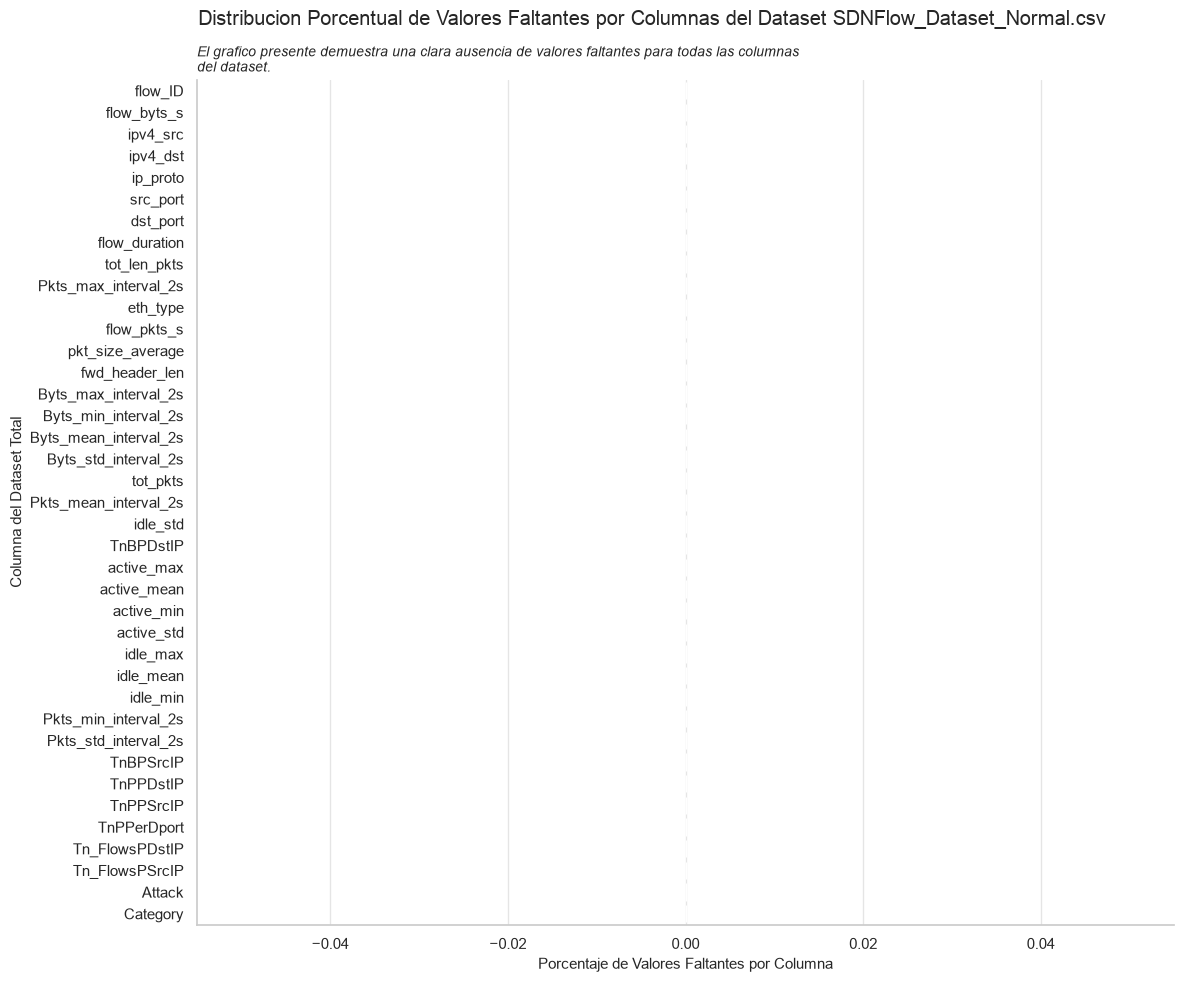

In [71]:
#! Graficamos el porcentaje de faltantes por columna, y si el dataset tiene menos de 30 columnas, graficamos un mapa de calor de los faltantes
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette="crest", ax=axes)
plt.suptitle(f"Distribucion Porcentual de Valores Faltantes por Columnas del Dataset {DATA_PATH.name}" ,x=0.55)
plt.title('El grafico presente demuestra una clara ausencia de valores faltantes para todas las columnas\ndel dataset.', loc='left', x=0, fontdict={
    'style':'italic',
    'size':10
})
plt.xlabel("Porcentaje de Valores Faltantes por Columna")
plt.ylabel("Columna del Dataset Total")
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
finalize_figure("01_faltantes_por_columna")


## Seccion 4: Analisis de la variable objetivo

Se cuantifica la distribucion de `Category`, su desbalance y la presencia de las siete clases esperadas. Este cuaderno no rebalancea el dataset.


### Exploracion de los registros por tipo de trafico dentro del dataset, mostrando conteos totales porcentaje y ordenamiento por cantidad de registros

In [14]:
#! Normalizamos la columna Category para obtener una representacion unica de todos los posibles valores de la columna sin duplicados
category_normalized = normalize_category_series(df.Category)

#? Calculamos el total de las columnas bajo el nombre de Class en lugar de Category, registrando el valor bajo la columna de Count
category_distribution = category_normalized.value_counts(dropna=False).rename_axis("Class").reset_index(name="Count")
#? Calculamos el porcentaje con la longitud total del dataframe original
category_distribution["Percentage"] = category_distribution["Count"] / len(df) * 100.0
#? Calculamos el ranking de cada clase segun su cantidad de registros, asignando un valor entero a cada clase
category_distribution["Rank"] = category_distribution["Count"].rank(method="dense", ascending=False).astype(int)

#! Calculamos en base al ranking anterior la clase con mas y menos registros
majority_class = category_distribution.iloc[0]["Class"] if not category_distribution.empty else None
minority_class = category_distribution.iloc[-1]["Class"] if not category_distribution.empty else None

#! Presentamos todos los resultados
print(f"Clase mayoritaria: {majority_class}")
print(f"Clase minoritaria: {minority_class}")
print(f"Todas las clases esperadas presentes: {set(EXPECTED_CLASSES).issubset(set(category_normalized.dropna().unique()))}")
display(category_distribution[["Class", "Count", "Percentage", "Rank"]])

Clase mayoritaria: HTTP
Clase minoritaria: NTP
Todas las clases esperadas presentes: True


,Class,Count,Percentage,Rank
0,HTTP,164974,74.458847,1
1,DNS,53551,24.16954,2
2,STREAMING,1487,0.671138,3
3,SSH,1133,0.511365,4
4,ICMP,305,0.137658,5
5,FTP,91,0.041072,6
6,NTP,23,0.010381,7


### Exploracion visual de la frecuencia de registros por clase de trafico registrada en Category

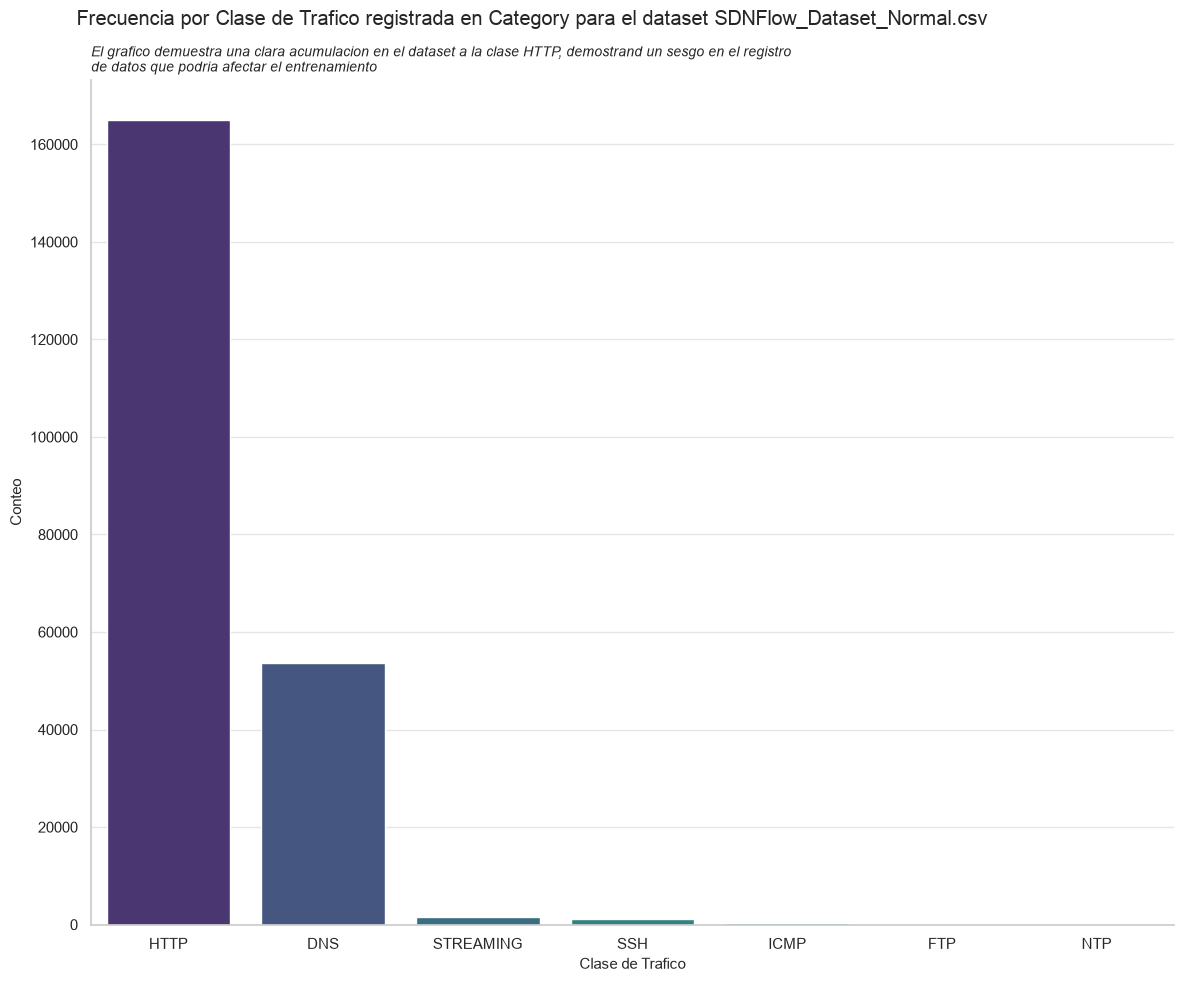

In [88]:
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.barplot(data=category_distribution, x="Class", y="Count", palette="viridis", ax=axes)
plt.suptitle(f"Frecuencia por Clase de Trafico registrada en Category para el dataset {DATA_PATH.name}",x=0.45)
plt.title('El grafico demuestra una clara acumulacion en el dataset a la clase HTTP, demostrand un sesgo en el registro\nde datos que podria afectar el entrenamiento', loc="left", x=0, fontdict={
    'style':'italic',
    'size':10
})
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
plt.xlabel("Clase de Trafico")
plt.ylabel("Conteo")


finalize_figure("04_clase_frecuencia")

### Exploracion visual del porcentaje de cada clase de Category

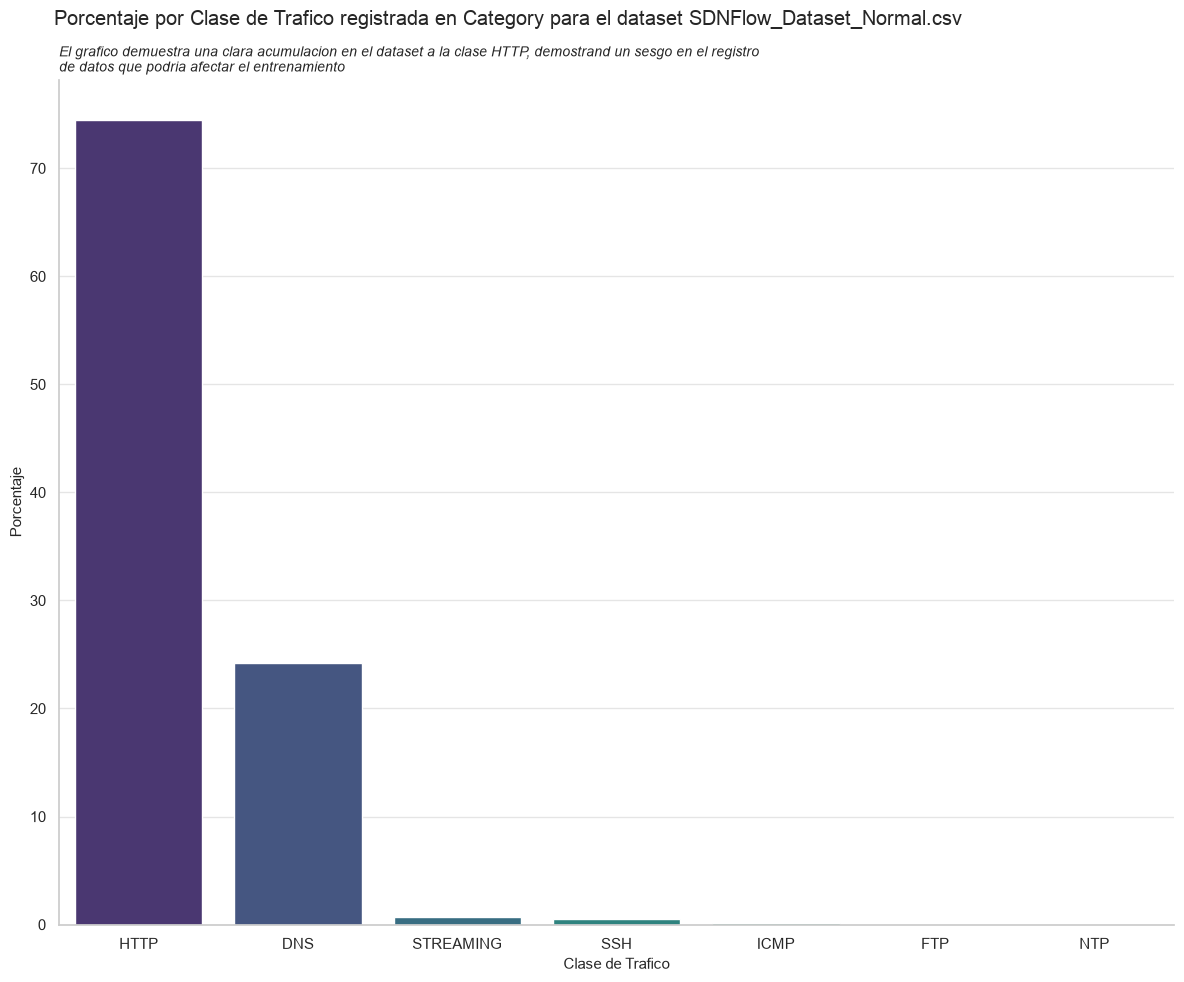

In [92]:
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.barplot(data=category_distribution, x="Class", y="Percentage", palette="viridis", ax=axes)
plt.suptitle(f"Porcentaje por Clase de Trafico registrada en Category para el dataset {DATA_PATH.name}",x=0.43)
plt.title('El grafico demuestra una clara acumulacion en el dataset a la clase HTTP, demostrand un sesgo en el registro\nde datos que podria afectar el entrenamiento', loc="left", x=0, fontdict={
    'style':'italic',
    'size':10
})
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
plt.xlabel("Clase de Trafico")
plt.ylabel("Porcentaje")
finalize_figure("05_clase_porcentaje")

## Seccion 5: Analisis univariado de las variables seleccionadas

Cada feature se evalua de forma individual y en relacion con `Category`. Para medidas que requieren valores validos, se usa una vista analitica normalizada sin modificar `df_raw`.


### Exploracion numerica de la cantidad de entradas del dataset utilizables para el entrenamiento del modelo en base a sus columnas claves

In [95]:
#! Generamos una copia del dataframe actual para el analisis en esta seccion
df_analysis = df.copy(deep=True)

#? Filtramos todas las columnas para aplicar una normalizacion en nombres
df_analysis.columns = [str(column).strip() for column in df_analysis.columns]

#? Aplicamos la misma normalizacion de variables categoricas para reducir posibles variaciones de nombres en la columna de analisis local
df_analysis[TARGET_COLUMN] = normalize_category_series(df_analysis[TARGET_COLUMN])

#? Para cada una de las columnas features que se usaran para el entrenamiento, se aplica una transformacion a valores numericos, para evitar analisis de variables tipo Object
for feature in FEATURE_COLUMNS:
    df_analysis[feature] = pd.to_numeric(df_analysis[feature], errors="coerce")

#! Realizamos una mascara binaria sobre la columna de target para explorar cuantas instancias de esta contiene una entrada que puede ser usada para
#! el entrenamiento del modelo
analysis_valid_mask = df_analysis[TARGET_COLUMN].isin(EXPECTED_CLASSES)
for feature, bounds in FEATURE_RULES.items():
    #? Anade a la mascara original un bitwise and sobre aquellas entradas que no son nulas
    analysis_valid_mask &= df_analysis[feature].notna()
    #? Hacemos lo mismo pero en este caso aplicamos una revision si el resultado de una operacion modulo es 0, lo que retiene valores enteros
    analysis_valid_mask &= np.isclose(df_analysis[feature] % 1, 0)
    #? Finalmente hacemos una revision sobre los rangos posibles de las variables definidas en FEATURE_RULES al inicio del notebook
    analysis_valid_mask &= df_analysis[feature].between(bounds["min"], bounds["max"])

#! Finalmente convertimos a int64 aquellas columnas seleccionadas en las columnas de entrenamiento que serian todas enteras,o deberian de serlo
df_analysis_valid = df_analysis.loc[analysis_valid_mask, TRAINING_COLUMNS].copy()
for feature in FEATURE_COLUMNS:
    df_analysis_valid[feature] = df_analysis_valid[feature].astype("Int64")

#! Presentamos resultados con la cantidad de entradas utilizables para el entrenamiento y su head
print(f"Filas validas para analisis de variables seleccionadas: {len(df_analysis_valid):,}")
display(df_analysis_valid.head())


Filas validas para analisis de variables seleccionadas: 221,564


,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


### Exploracion numerica de la distribucion de valores correspondientes al tipo de paquete registrado, es decir IPv4 solo, IPv4 e IPv6, etc.

En este caso, el objetivo es determinar si el modelo aprendera sobre paquetes de tipo IPv6 adicionalmente, y si sera necesario una restructuracion del modelo de prueba

In [96]:
#! Calculamos el conteo de entradas de la columna de tipo eth_type, su porcentaje y su labela en base al mapeo definido inicialmente
eth_counts = df_analysis_valid["eth_type"].value_counts().rename_axis("eth_type").reset_index(name="count")
eth_counts["percentage"] = eth_counts["count"] / eth_counts["count"].sum() * 100.0
eth_counts["label"] = eth_counts["eth_type"].map(ETH_TYPE_LABELS).fillna("desconocido")
display(eth_counts)
#? Esta linea solo se imprime si lo unico que tenemos es IPv4
print(f"Solo IPv4 2048 presente: {set(df_analysis_valid['eth_type'].dropna().unique().tolist()) == {2048}}")

,eth_type,count,percentage,label
0,2048,221564,100.0,IPv4


Solo IPv4 2048 presente: True


### Exploracion visual de la distribucion de conteo de valores de eth_type

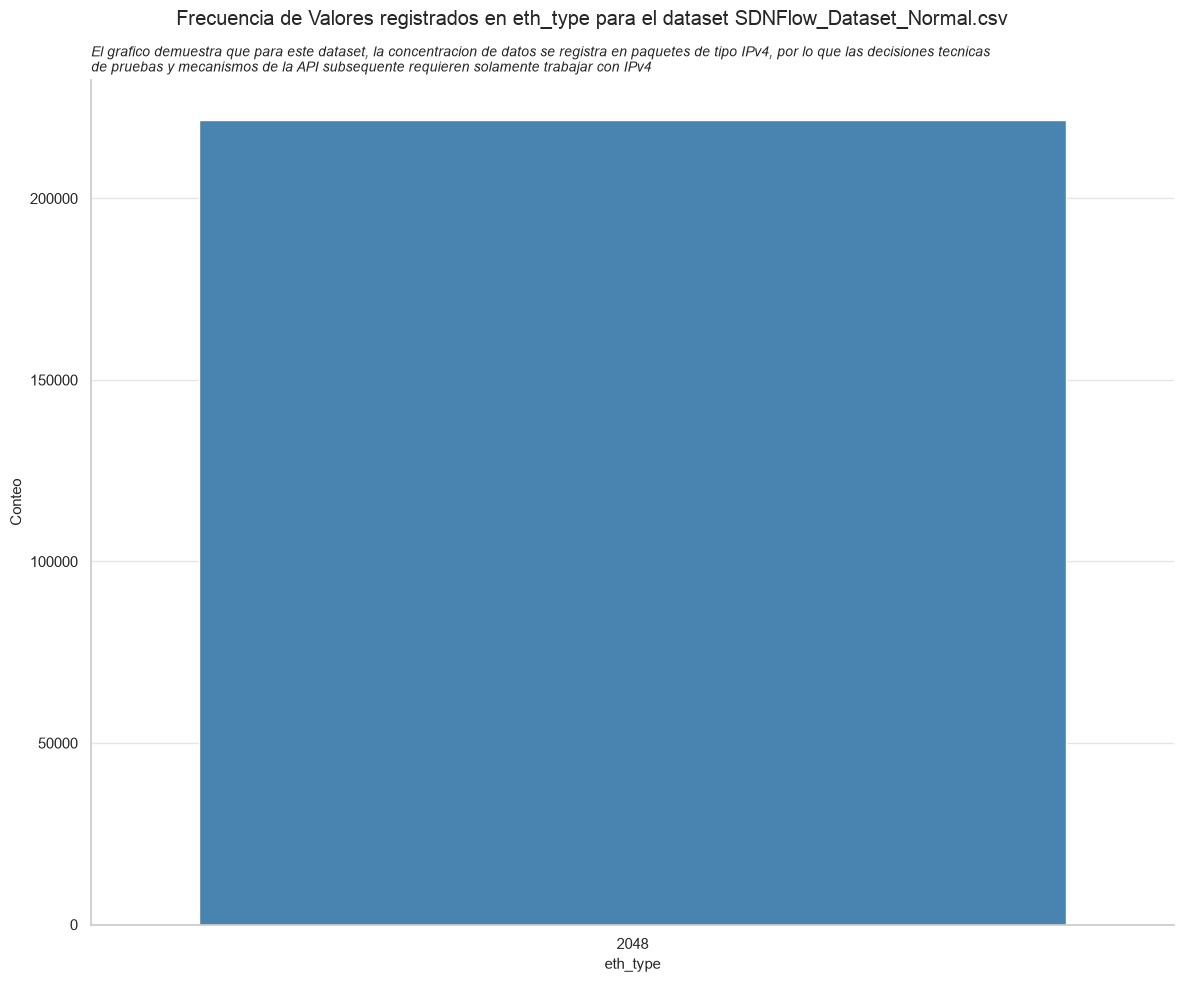

In [98]:
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.barplot(data=eth_counts, x="eth_type", y="count", palette="Blues_d", ax=axes)
plt.suptitle(f"Frecuencia de Valores registrados en eth_type para el dataset {DATA_PATH.name}", x=0.5)
plt.title('El grafico demuestra que para este dataset, la concentracion de datos se registra en paquetes de tipo IPv4, por lo que las decisiones tecnicas\nde pruebas y mecanismos de la API subsequente requieren solamente trabajar con IPv4', loc="left", x=0, fontdict={
    'style':'italic',
    'size':10
})
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
plt.xlabel("eth_type")
plt.ylabel("Conteo")
finalize_figure("08_eth_type_frecuencia")

### Exploracion visual de la distribucion de valores normalizados de Category con respecto a Eth Type

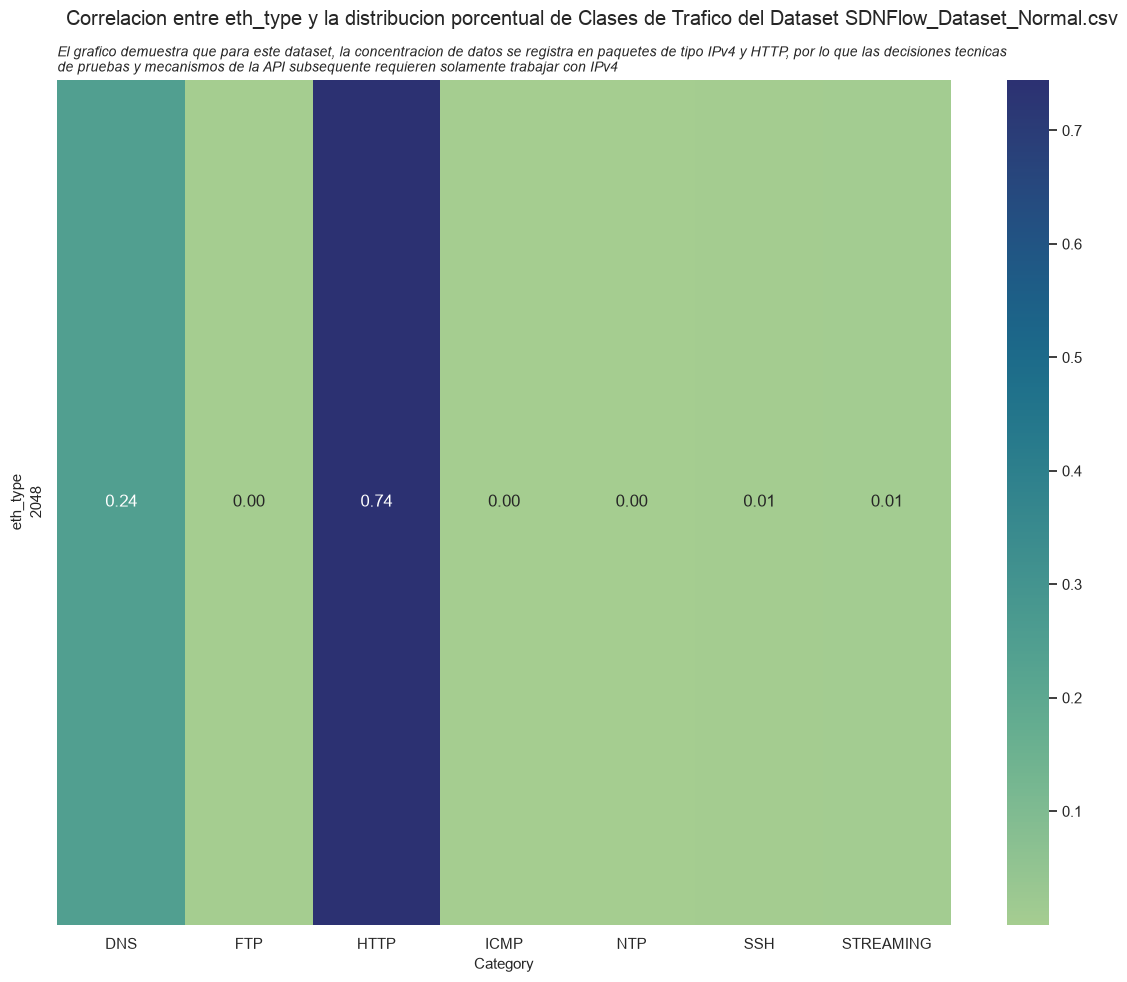

In [99]:
eth_by_class = pd.crosstab(df_analysis_valid["eth_type"], df_analysis_valid[TARGET_COLUMN], normalize="index")
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.heatmap(eth_by_class, annot=True, fmt=".2f", cmap="crest", ax=axes)
plt.suptitle(f"Correlacion entre eth_type y la distribucion porcentual de Clases de Trafico del Dataset {DATA_PATH.name}", x=0.5)
plt.title('El grafico demuestra que para este dataset, la concentracion de datos se registra en paquetes de tipo IPv4 y HTTP, por lo que las decisiones tecnicas\nde pruebas y mecanismos de la API subsequente requieren solamente trabajar con IPv4', loc="left", x=0, fontdict={
    'style':'italic',
    'size':10
})
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
plt.xlabel("Category")
plt.ylabel("eth_type")
finalize_figure("09_eth_type_por_clase")

### Exploracion numerica de la cantidad de registros y porcentajes asociados con el Protocolo IP usado en los Flows registrados

In [100]:
#! Conteo de valores de ip_proto, correspondiente a 1 ICMP, 6 TCP y 17 UDP
proto_counts = df_analysis_valid["ip_proto"].value_counts().rename_axis("ip_proto").reset_index(name="count")
proto_counts["percentage"] = proto_counts["count"] / proto_counts["count"].sum() * 100.0
proto_counts["label"] = proto_counts["ip_proto"].map(IP_PROTO_LABELS).fillna("desconocido")
display(proto_counts)


,ip_proto,count,percentage,label
0,6,166475,75.136304,TCP
1,17,54784,24.726039,UDP
2,1,305,0.137658,ICMP


### Exploracion visual de la distribucion de frecuencia de los valores normalizados y registrados dento de ip_proto

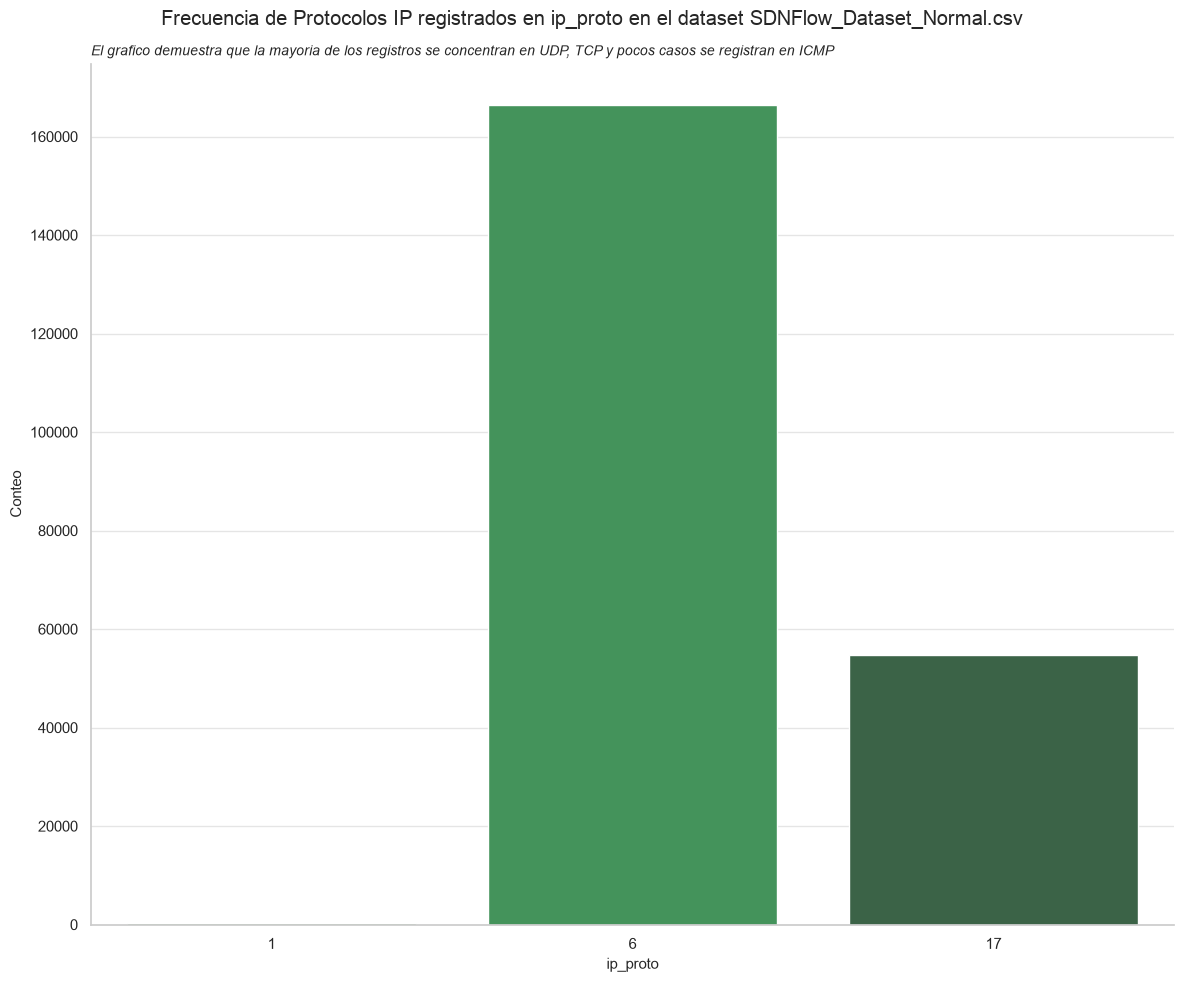

In [101]:
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.barplot(data=proto_counts, x="ip_proto", y="count", palette="Greens_d", ax=axes)
plt.suptitle(f"Frecuencia de Protocolos IP registrados en ip_proto en el dataset {DATA_PATH.name}", x=0.5)
plt.title('El grafico demuestra que la mayoria de los registros se concentran en UDP, TCP y pocos casos se registran en ICMP', loc="left", x=0, fontdict={
    'style':'italic',
    'size':10
})
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
plt.xlabel("ip_proto")
plt.ylabel("Conteo")
finalize_figure("10_ip_proto_frecuencia")

### Exploracion visual de la distribucion de valores de Protocolo IP registrado con respecto a las Clases de Trafico de Category

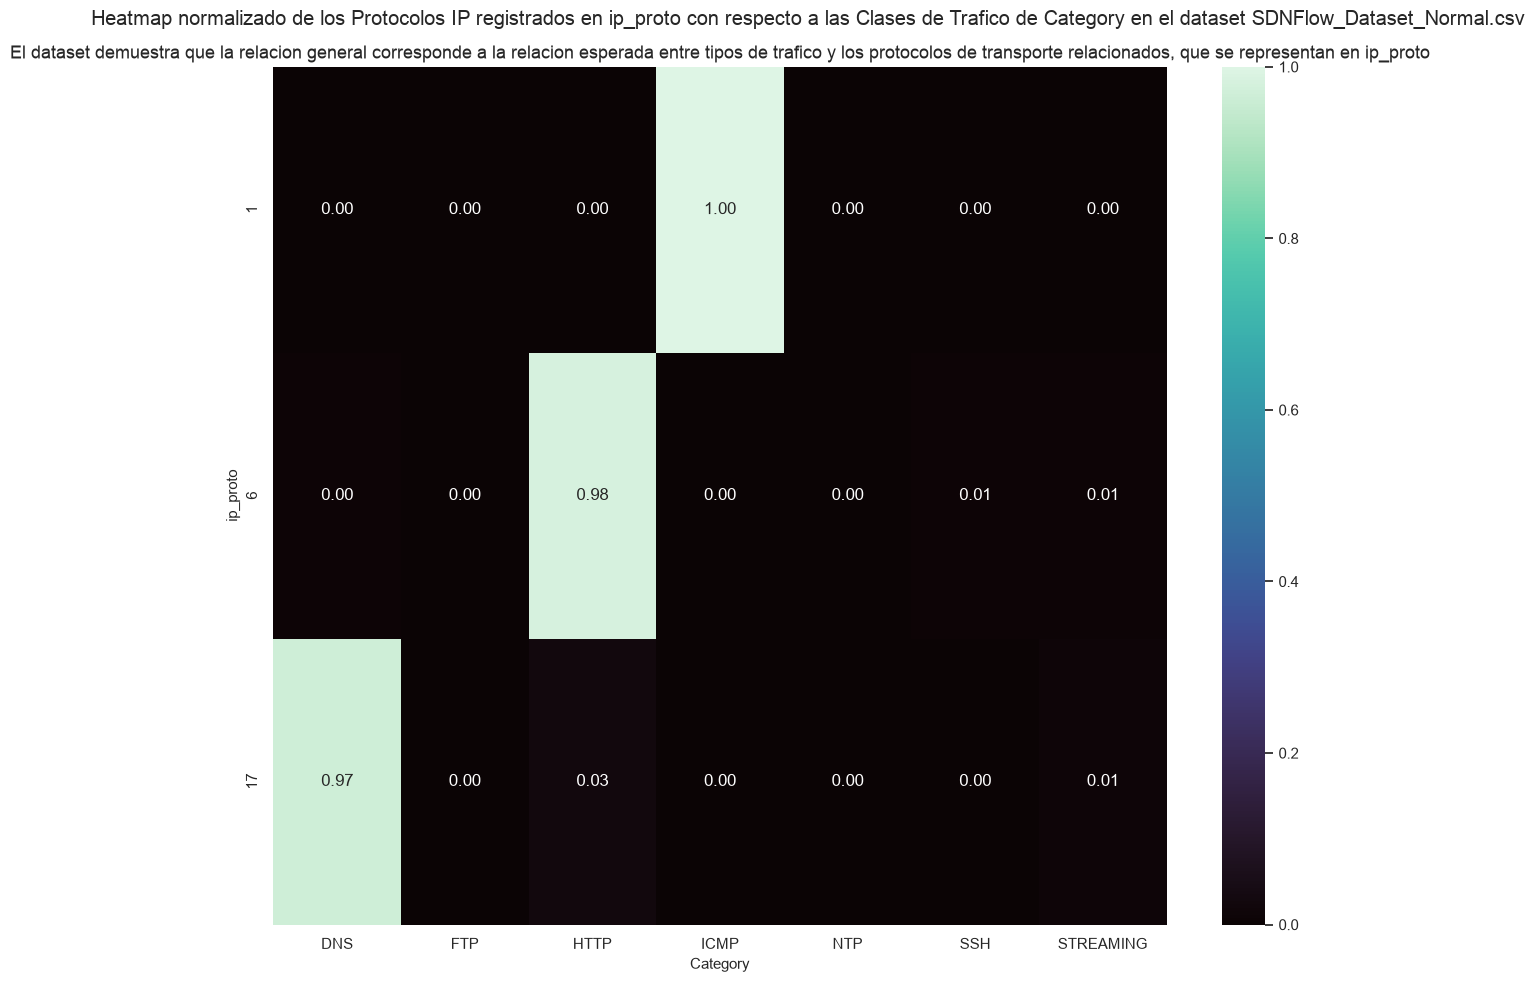

ip_proto,1,6,17
Category,,,
DNS,0.0,0.003910,0.965610
FTP,0.0,0.000547,0.000000
HTTP,0.0,0.982424,0.026011
ICMP,1.0,0.000000,0.000000
NTP,0.0,0.000000,0.000420
SSH,0.0,0.006806,0.000000
STREAMING,0.0,0.006313,0.007959


In [102]:
proto_by_class = pd.crosstab(df_analysis_valid["ip_proto"], df_analysis_valid[TARGET_COLUMN], normalize="index")
fig, axes = plt.subplots(1,1,figsize=(12, 10))
sns.heatmap(proto_by_class, annot=True, fmt=".2f", cmap="mako", ax=axes)
plt.suptitle(f"Heatmap normalizado de los Protocolos IP registrados en ip_proto con respecto a las Clases de Trafico de Category en el dataset {DATA_PATH.name}", x=0.5)
plt.title('El dataset demuestra que la relacion general corresponde a la relacion esperada entre tipos de trafico y los protocolos de transporte relacionados, que se representan en ip_proto')

plt.xlabel("Category")
plt.ylabel("ip_proto")
finalize_figure("11_ip_proto_heatmap")
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
class_within_proto = pd.crosstab(df_analysis_valid[TARGET_COLUMN], df_analysis_valid["ip_proto"], normalize="columns")
display(class_within_proto)

### Exploracion visual y numerica de los diferentes tipos de puertos (src y des) registrados en el dataset

In [105]:
#! Definimos una funcion previa para la generacion de los graficos y tablas de cada seccion de analisis
def analyze_port_feature(
    frame: pd.DataFrame,
    feature: str,
) -> pd.DataFrame:
    """Analiza numerica y visualmente una variable de puerto.

    La funcion estudia una columna que representa puertos de transporte,
    normalmente ``src_port`` o ``dst_port``. El analisis incluye calidad de
    datos, estadisticas descriptivas, rangos administrativos de puertos,
    valores poco frecuentes, deteccion estadistica de valores extremos y
    distintas visualizaciones.

    Paso a paso:

    1. Comprueba que ``frame`` sea un ``DataFrame``.
    2. Comprueba que la variable exista en el conjunto de datos.
    3. Convierte la variable a formato numerico sin detener la ejecucion por
       valores no convertibles.
    4. Identifica valores nulos, no numericos, infinitos, no enteros y fuera
       del rango permitido para puertos.
    5. Conserva solamente puertos enteros validos entre 0 y 65535.
    6. Calcula estadisticas descriptivas generales.
    7. Cuenta puertos cero, privilegiados, registrados y dinamicos.
    8. Calcula cardinalidad y cantidad de valores que aparecen una sola vez.
    9. Calcula limites IQR y cantidad de valores extremos estadisticos.
    10. Muestra una tabla resumen.
    11. Genera una muestra reproducible para graficos costosos.
    12. Genera un histograma de valores originales.
    13. Genera un histograma logaritmico para puertos positivos.
    14. Genera un boxplot.
    15. Grafica los puertos mas frecuentes.
    16. Grafica la distribucion por rango administrativo.
    17. Devuelve la tabla resumen.

    Args:
        frame: Conjunto de datos que contiene la variable de puerto.
        feature: Nombre de la columna que se desea analizar.

    Returns:
        ``DataFrame`` de una fila con estadisticas de calidad, distribucion,
        cardinalidad, rangos administrativos y valores extremos.

    Raises:
        TypeError: Si ``frame`` no es un ``DataFrame`` o si ``feature`` no es
            una cadena.
        ValueError: Si ``feature`` esta vacio, si la columna no contiene
            ningun puerto valido o si la configuracion de graficos es invalida.
        KeyError: Si ``feature`` no existe en ``frame``.

    Notes:
        Los valores identificados como extremos por IQR no se eliminan. Los
        numeros de puerto son identificadores discretos y un puerto raro puede
        ser completamente valido.

        El analisis IQR se incluye como diagnostico estadistico, no como regla
        automatica de limpieza.
    """
    if not isinstance(frame, pd.DataFrame):
        raise TypeError("frame debe ser un DataFrame de Pandas.")
    if not isinstance(feature, str):
        raise TypeError("feature debe ser una cadena.")
    feature = feature.strip()
    if not feature:
        raise ValueError("feature no puede estar vacio.")
    if feature not in frame.columns:
        raise KeyError(
            f"La columna '{feature}' no existe en el DataFrame."
        )
    if TOP_N_PORTS <= 0:
        raise ValueError(
            "TOP_N_PORTS debe ser mayor que cero."
        )
    if SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS <= 0:
        raise ValueError(
            "SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS debe ser mayor que cero."
        )

    #! Conservamos la serie original para diagnosticar problemas de calidad.
    raw_series = frame[feature]
    numeric_series = pd.to_numeric(
        raw_series,
        errors="coerce",
    )
    numeric_array = numeric_series.to_numpy(
        dtype=float,
        na_value=np.nan,
    )
    genuine_null_mask = raw_series.isna()
    non_numeric_mask = (
        raw_series.notna()
        & numeric_series.isna()
    )
    infinite_mask = pd.Series(
        np.isinf(numeric_array),
        index=frame.index,
    )
    finite_mask = pd.Series(
        np.isfinite(numeric_array),
        index=frame.index,
    )
    non_integral_mask = pd.Series(
        False,
        index=frame.index,
    )

    #! Seleccionamos solamente valores finitos para calcular su parte decimal.
    finite_values = numeric_series.loc[finite_mask]

    #! Marcamos como valores no enteros aquellos cuya parte decimal exista luego de hacer modulo 1
    non_integral_mask.loc[finite_mask] = ~np.isclose(
        np.mod(
            finite_values.to_numpy(dtype=float),
            1.0,
        ),
        0.0,
    )
    below_range_mask = (
        finite_mask
        & numeric_series.lt(0)
    )
    above_range_mask = (
        finite_mask
        & numeric_series.gt(65535)
    )

    #! Definimos como validos solo los numeros finitos, enteros y dentro de rango.
    valid_mask = (
        finite_mask
        & ~non_integral_mask
        & ~below_range_mask
        & ~above_range_mask
    )

    #! Extraemos los puertos validos y usa un tipo entero nullable.
    valid_series = (
        numeric_series.loc[valid_mask]
        .round()
        .astype("Int64")
    )
    if valid_series.empty:
        raise ValueError(
            f"La columna '{feature}' no contiene puertos validos."
        )


    summary = describe_numeric_series(valid_series)
    summary["total_rows"] = int(len(frame))
    summary["valid_port_count"] = int(valid_series.count())
    summary["genuine_null_count"] = int(
        genuine_null_mask.sum()
    )
    summary["non_numeric_count"] = int(
        non_numeric_mask.sum()
    )
    summary["infinite_count"] = int(
        infinite_mask.sum()
    )
    summary["non_integral_count"] = int(
        non_integral_mask.sum()
    )
    summary["below_range_count"] = int(
        below_range_mask.sum()
    )
    summary["above_range_count"] = int(
        above_range_mask.sum()
    )
    summary["zero_count"] = int(
        valid_series.eq(0).sum()
    )
    summary["well_known_count"] = int(
        valid_series.between(
            0,
            1023,
            inclusive="both",
        ).sum()
    )
    summary["registered_count"] = int(
        valid_series.between(
            1024,
            49151,
            inclusive="both",
        ).sum()
    )
    summary["dynamic_count"] = int(
        valid_series.between(
            49152,
            65535,
            inclusive="both",
        ).sum()
    )
    summary["unique_count"] = int(
        valid_series.nunique(dropna=True)
    )
    value_counts = valid_series.value_counts(
        dropna=True
    )
    summary["rare_values_count"] = int(
        value_counts.eq(1).sum()
    )

    #! Realizamos los calculos de los cuartiles de los puertos registrados
    q1 = float(valid_series.quantile(0.25))
    q3 = float(valid_series.quantile(0.75))
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    summary["q1"] = q1
    summary["q3"] = q3
    summary["iqr"] = float(iqr)
    summary["iqr_lower"] = float(iqr_lower)
    summary["iqr_upper"] = float(iqr_upper)

    #! usamos el rango interquartlier y sus limites iferiores y superiores para marcara los puertos fuera de rango
    outlier_mask = (
        valid_series.lt(iqr_lower)
        | valid_series.gt(iqr_upper)
    )
    summary["outlier_count"] = int(
        outlier_mask.sum()
    )

    summary_table = pd.DataFrame([summary])
    print()
    display(summary_table)
    print()


    #! Extraemos solo los datos validos tomados desde los filtros iniciales para la generacion de graficos
    valid_plot_frame = pd.DataFrame(
        {
            feature: valid_series.astype(int),
        }
    )
    plot_frame = random_sample_frame(
        valid_plot_frame,
        SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS,
    )

    #! Creamos un histograma sobre los puertos y su frecuencia en los datos reales
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    sns.histplot(
        data=plot_frame,
        x=feature,
        bins=50,
        kde=False,
        ax=ax,
    )
    plt.suptitle(f"Histograma de {feature}", x=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("Frecuencia")
    finalize_figure(f"12_{feature}_hist")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #! Conservamos solo valores positivos antes de aplicar logaritmo.
    positive_values = plot_frame.loc[
        plot_frame[feature] > 0,
        feature,
    ]

    #! Generamos el histograma logaritmico solo si existen valores positivos.
    if not positive_values.empty:
        log_values = np.log10(
            positive_values.astype(float)
        )
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        sns.histplot(
            x=log_values,
            bins=50,
            kde=False,
            ax=ax,
        )
        plt.suptitle(
            f"Histograma log10 de {feature} "
            "para valores positivos",
            x=0.5,
        )
        ax.set_xlabel(f"log10({feature})")
        ax.set_ylabel("Frecuencia")
        finalize_figure(f"13_{feature}_hist_log")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    print()
    #! Generamos un boxplot de los datos de la feature
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    sns.boxplot(
        data=plot_frame,
        x=feature,
        ax=ax,
    )
    plt.suptitle(f"Boxplot de {feature}", x=0.5)
    ax.set_xlabel(feature)
    finalize_figure(f"14_{feature}_boxplot")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    top_ports = (
        valid_series.value_counts()
        .head(TOP_N_PORTS)
        .rename_axis(feature)
        .reset_index(name="count")
    )

    top_ports[feature] = (
        top_ports[feature]
        .astype(int)
        .astype(str)
    )

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    sns.barplot(
        data=top_ports,
        x=feature,
        y="count",
        ax=ax,
    )
    plt.suptitle(
        f"Puertos mas frecuentes en {feature}",
        x=0.5,
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Conteo")
    plt.xticks(rotation=45, ha="right")
    finalize_figure(f"15_{feature}_top")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    range_series = port_bucket(valid_series)

    range_distribution = (
        range_series.value_counts(
            dropna=False,
            sort=False,
        )
        .rename_axis("range")
        .reset_index(name="count")
    )

    range_distribution["range"] = (
        range_distribution["range"]
        .astype("string")
        .fillna("OUT_OF_RANGE")
    )

    fig, ax = plt.subplots(1, 1, figsize=(12,10))
    sns.barplot(
        data=range_distribution,
        x="range",
        y="count",
        ax=ax,
    )
    plt.suptitle(
        f"Distribucion por rango de {feature}",
        x=0.5,
    )
    ax.set_xlabel("Rango")
    ax.set_ylabel("Conteo")
    plt.xticks(rotation=20, ha="right")
    finalize_figure(f"16_{feature}_rangos")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Devuelve el resumen para permitir su reutilizacion posterior.
    return summary_table

### Exploracion general de src_port

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23283.625174,443.0,23922.476216,443.0,46556.25,0.190069,-1.766745,221564,221564,0,0,0,0,0,0,305,111604,64691,45269,22369,6397,46113.25,-68726.875,115726.125,0


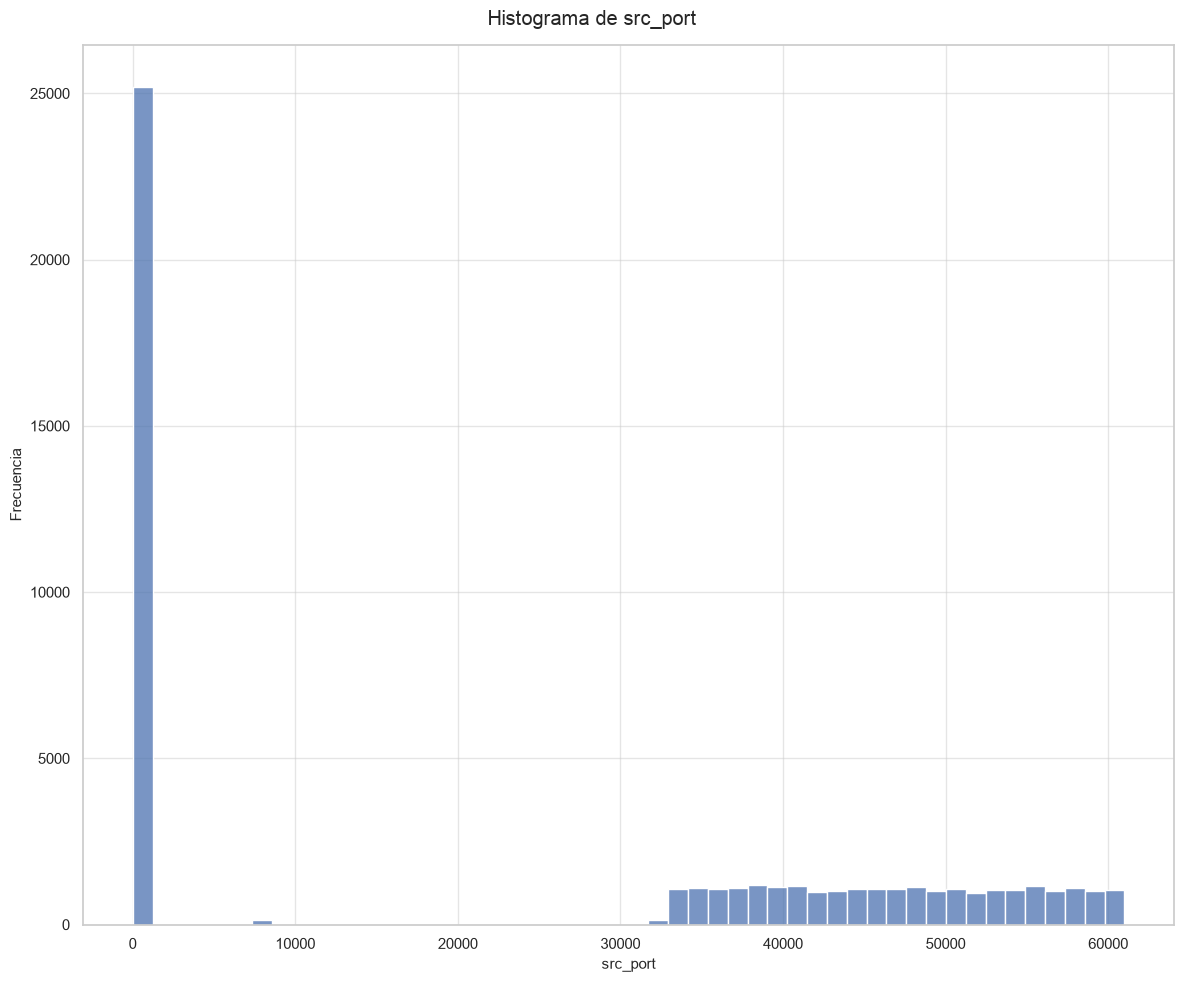

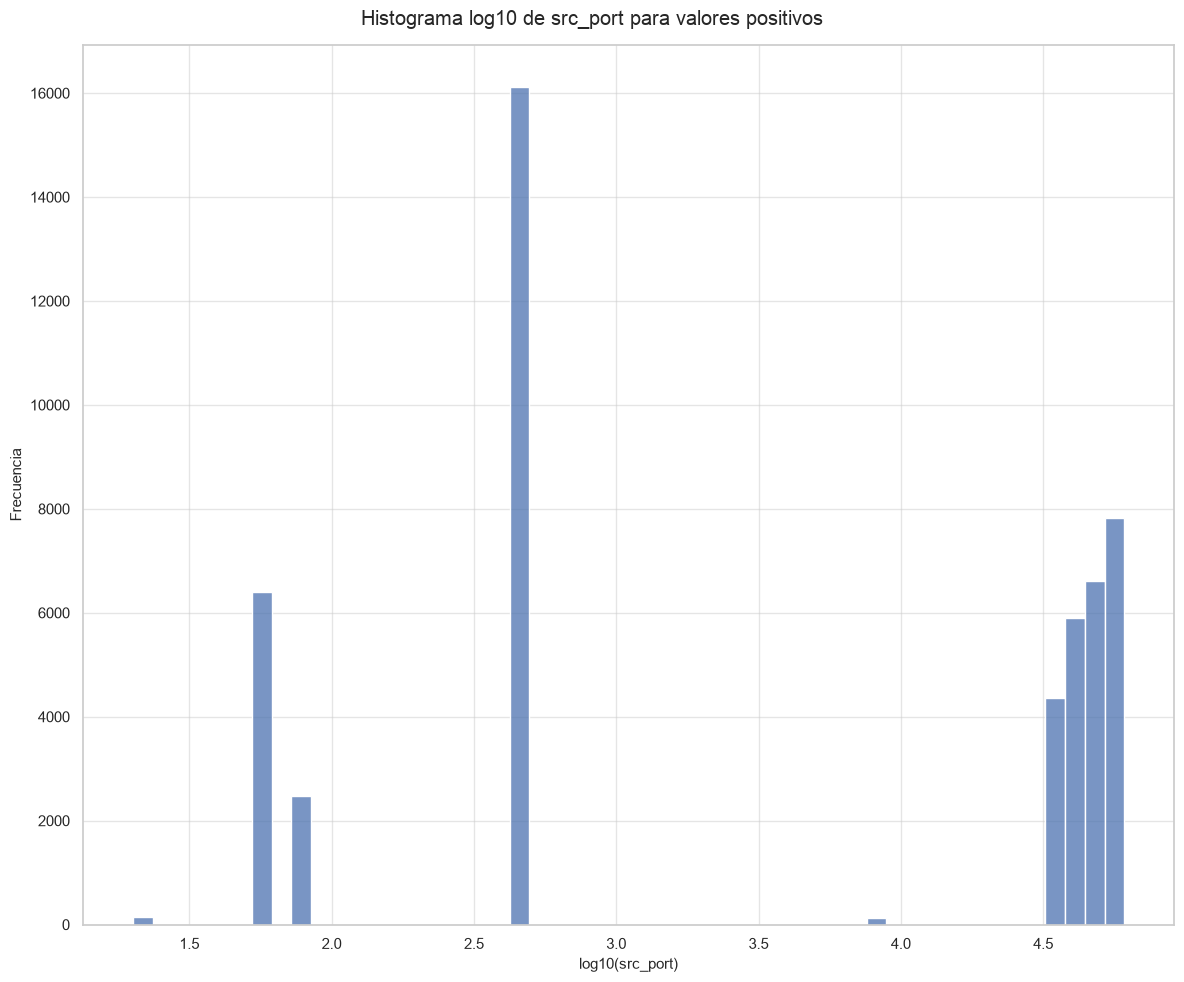

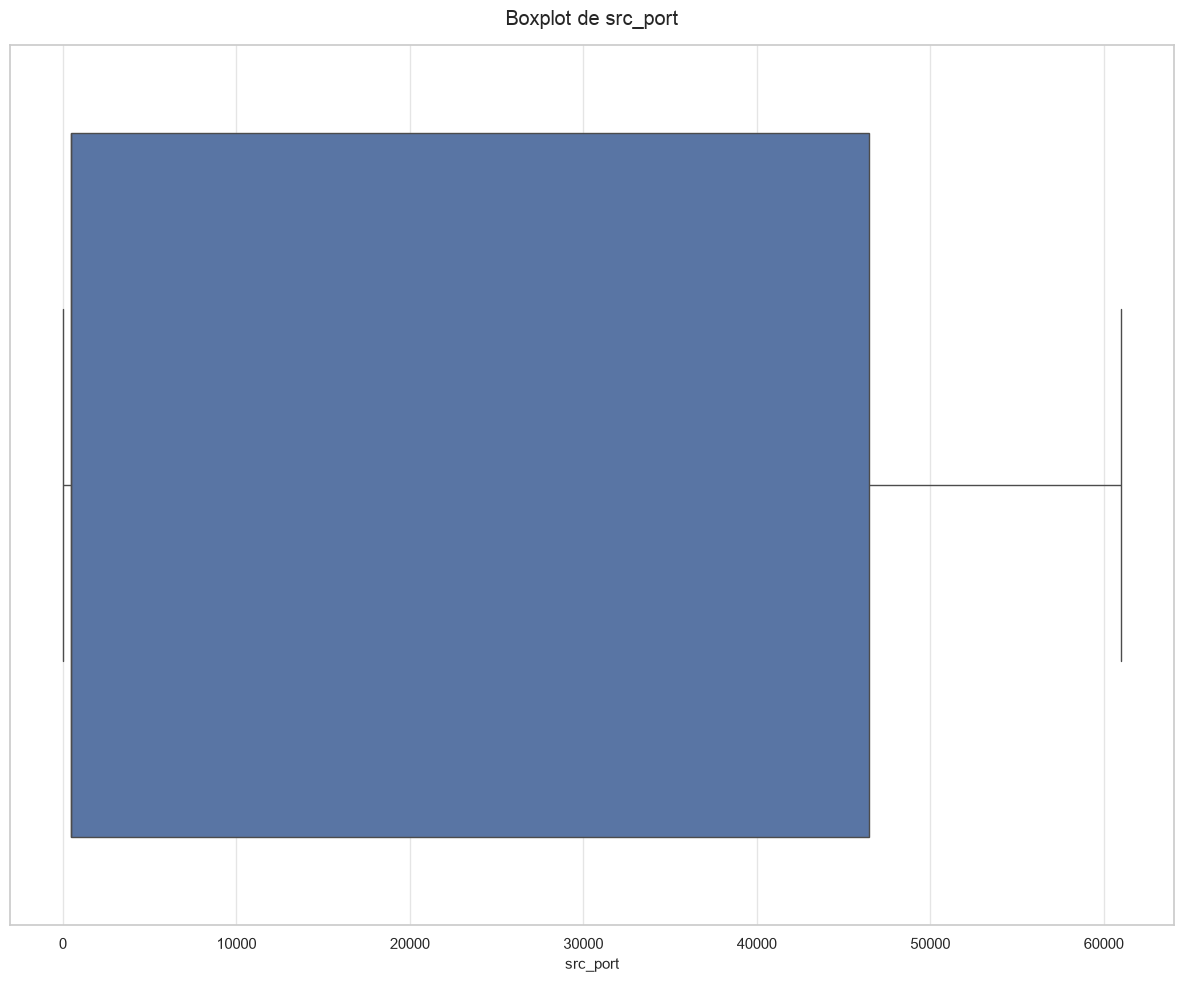

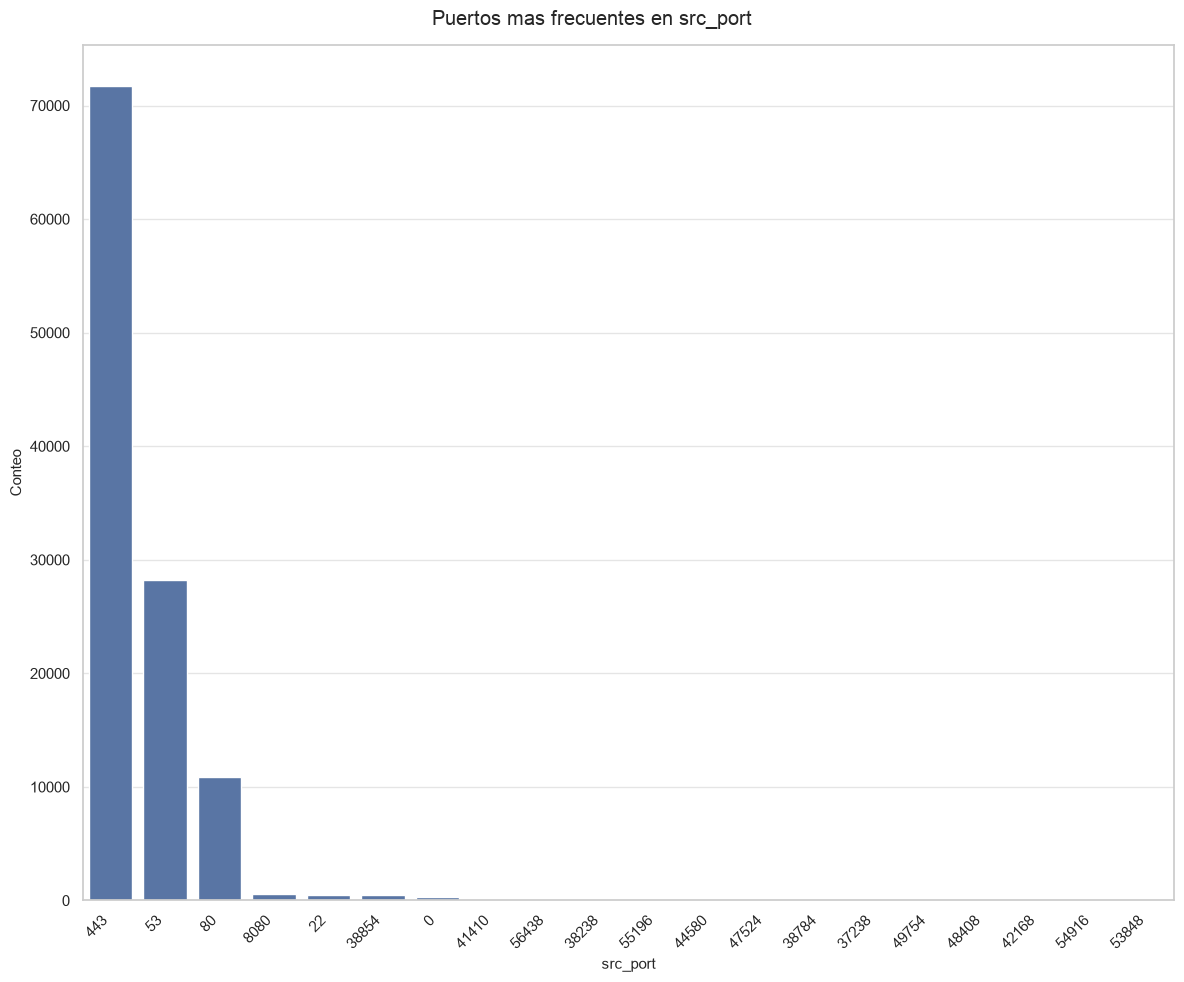

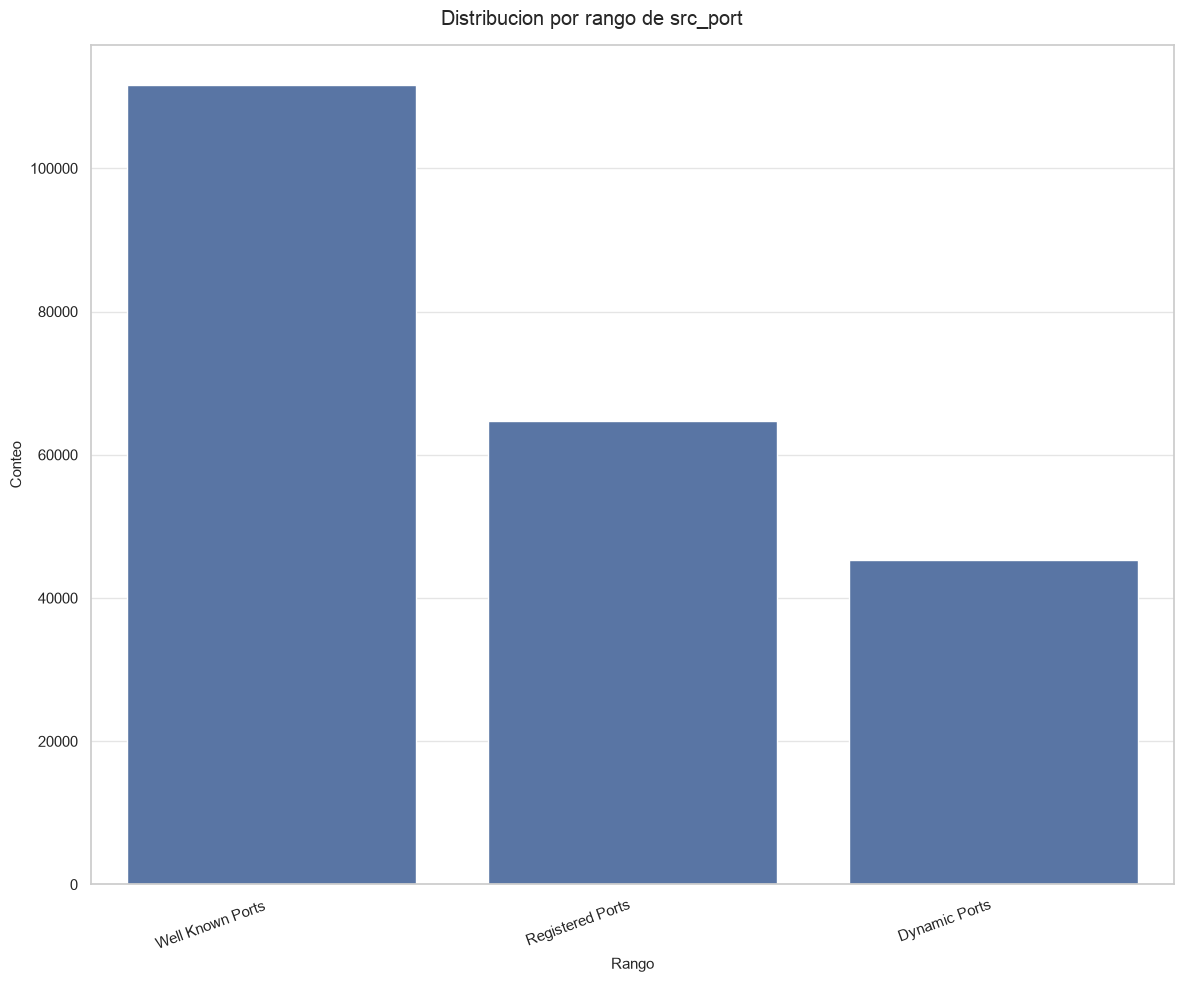

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23283.625174,443.0,23922.476216,443.0,46556.25,0.190069,-1.766745,221564,221564,0,0,0,0,0,0,305,111604,64691,45269,22369,6397,46113.25,-68726.875,115726.125,0


In [106]:
analyze_port_feature(df_analysis_valid, "src_port")

### Exploracion general de dst_port

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23806.910319,33076.0,23929.102073,443.0,46836.0,0.148177,-1.77737,221564,221564,0,0,0,0,0,0,305,108760,66595,46209,21964,5823,46393.0,-69146.5,116425.5,0


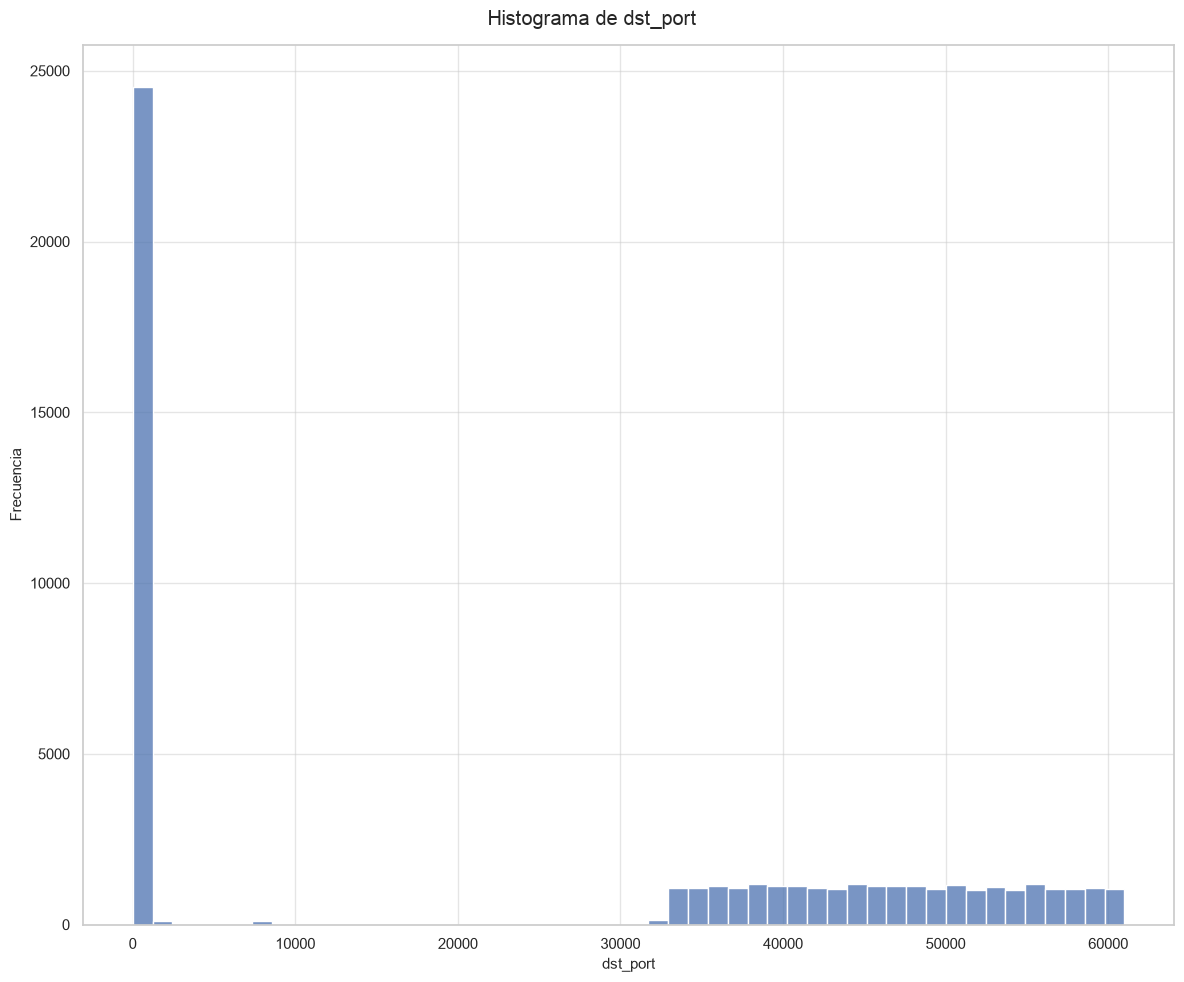

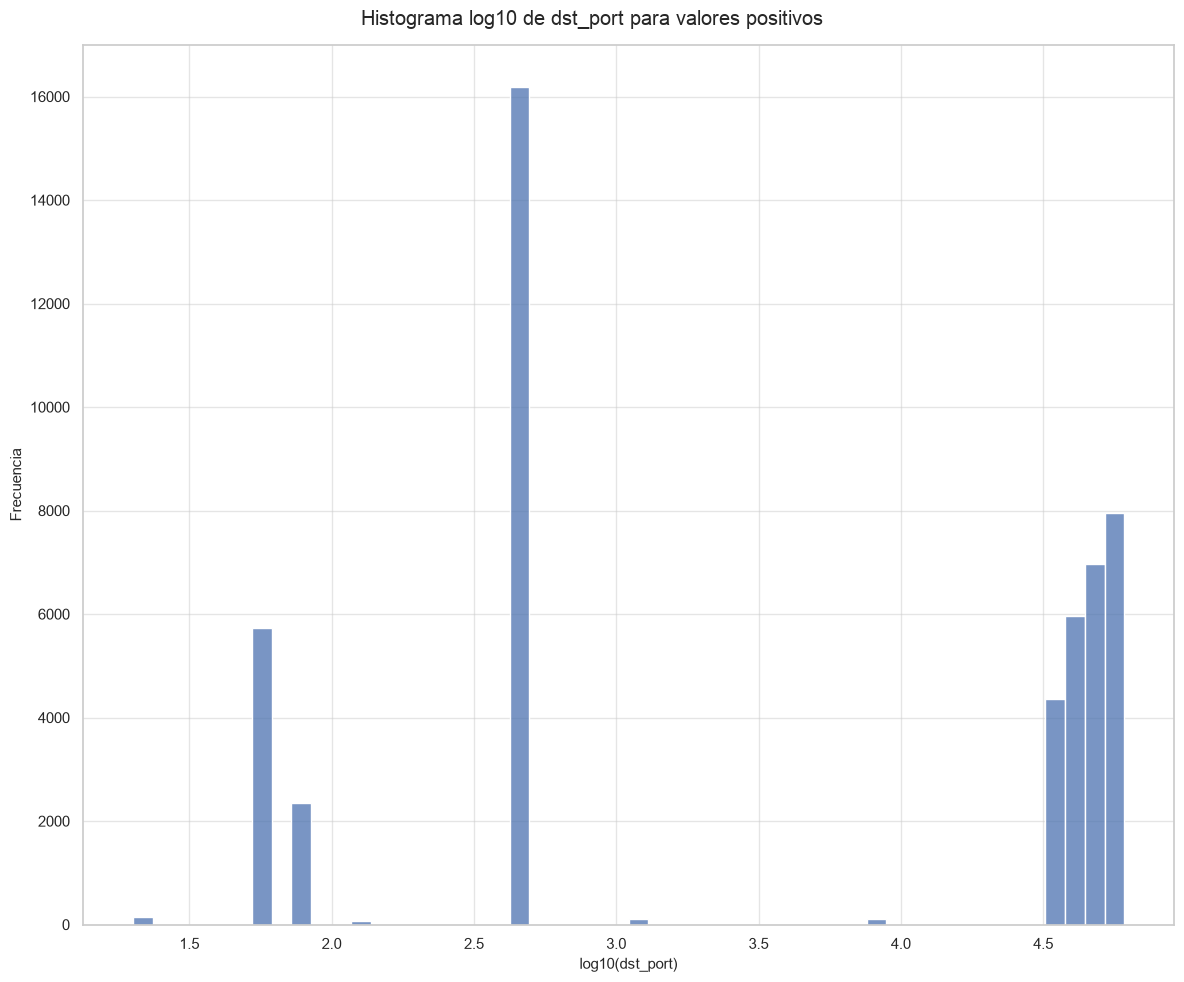

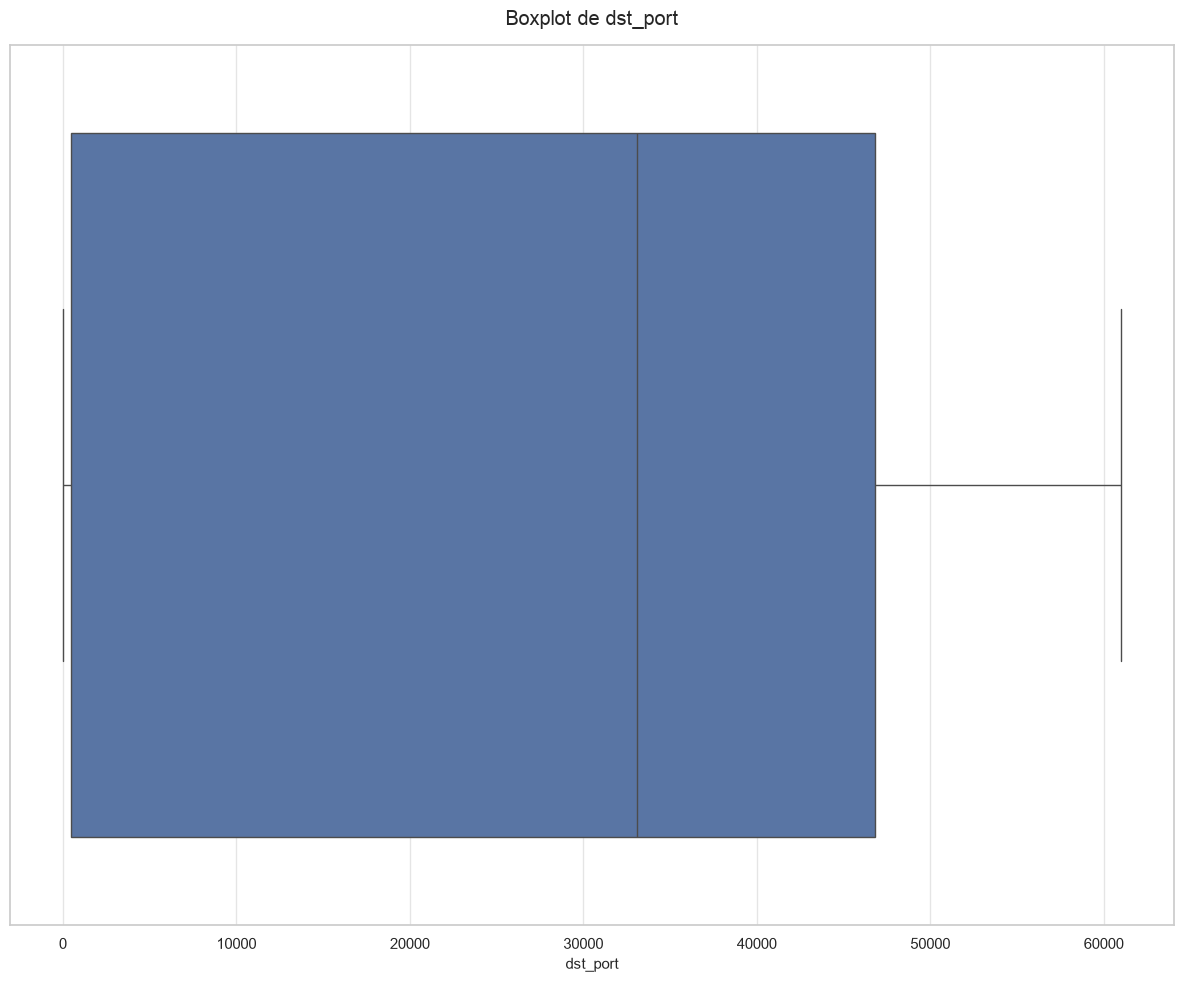

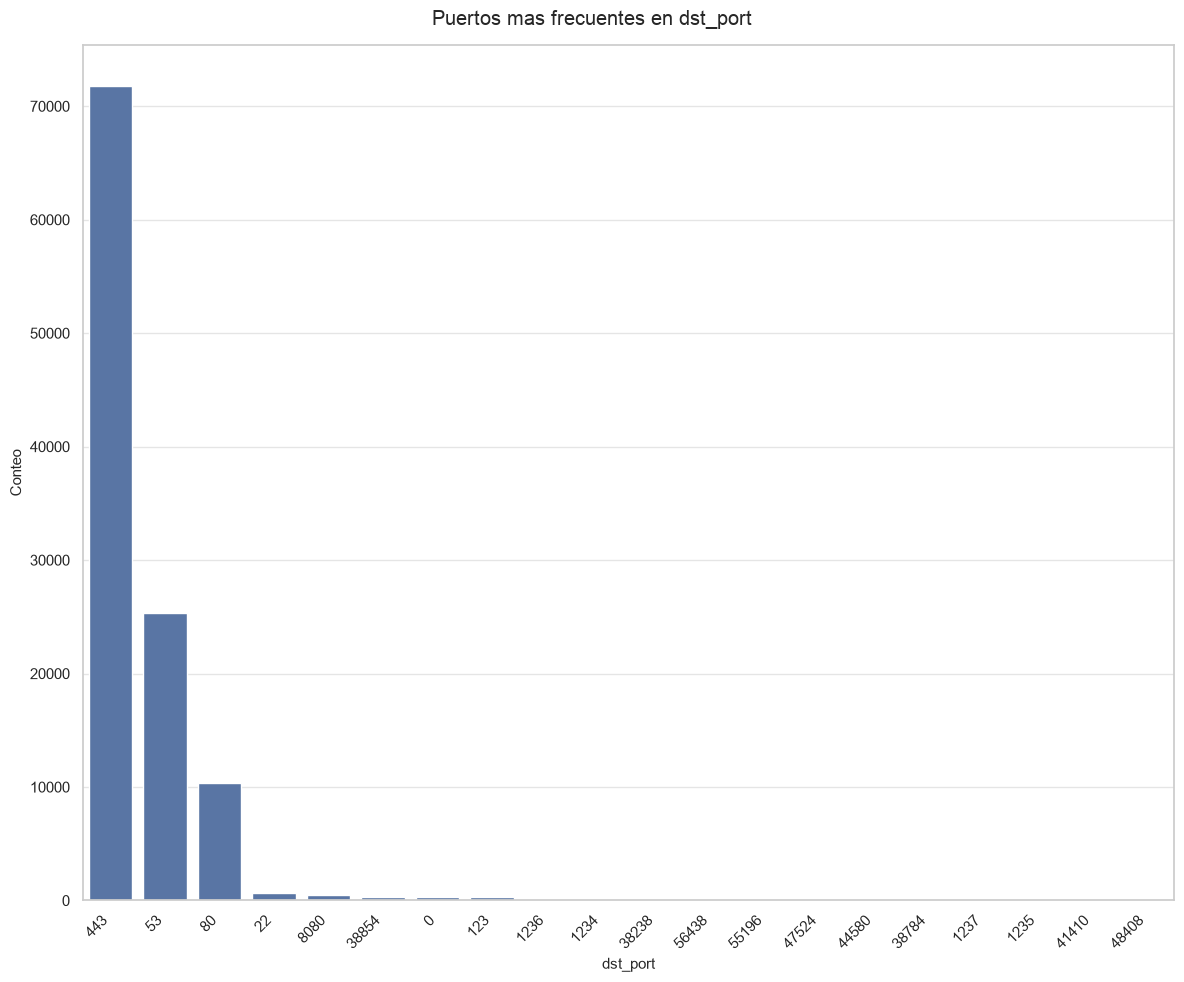

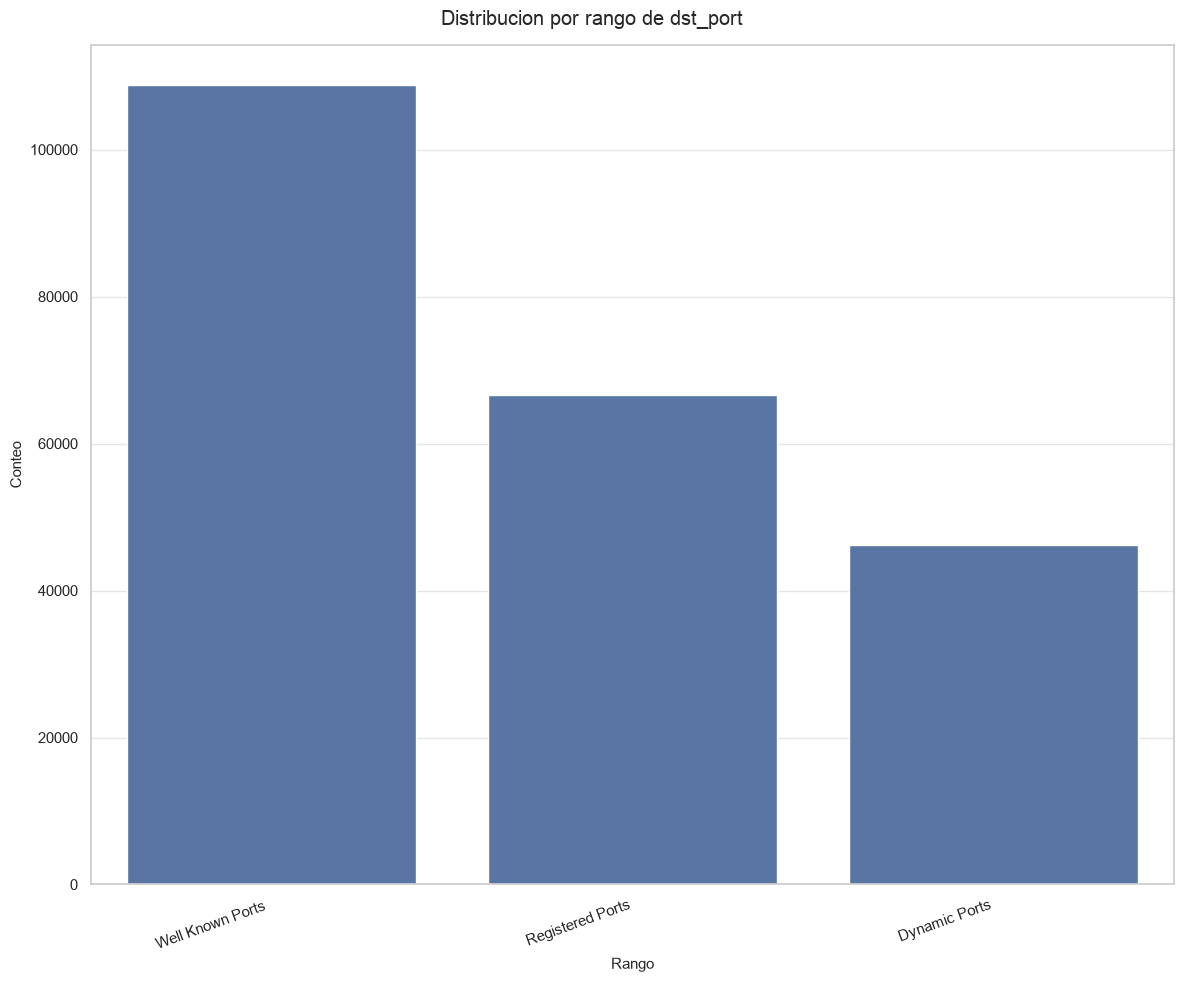

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23806.910319,33076.0,23929.102073,443.0,46836.0,0.148177,-1.77737,221564,221564,0,0,0,0,0,0,305,108760,66595,46209,21964,5823,46393.0,-69146.5,116425.5,0


In [107]:
analyze_port_feature(df_analysis_valid, "dst_port")

### Exploracion de puertos de destino comparado con las clases de trafico de Category

In [108]:
port_class_top = (
    df_analysis_valid.groupby(["dst_port", TARGET_COLUMN]).size().rename("count").reset_index()
    .sort_values("count", ascending=False)
)
display(port_class_top.head(30))



,dst_port,Category,count
8,443,HTTP,71787
4,53,DNS,25357
5,80,HTTP,10331
3,22,SSH,643
14,8080,STREAMING,471
6425,38854,SSH,320
0,0,ICMP,305
6,123,HTTP,263
11,1236,STREAMING,135
9,1234,STREAMING,127


### Exploracion visual de la correlacion entre los puertos de destino mas frecuentes y su Clase de Trafico

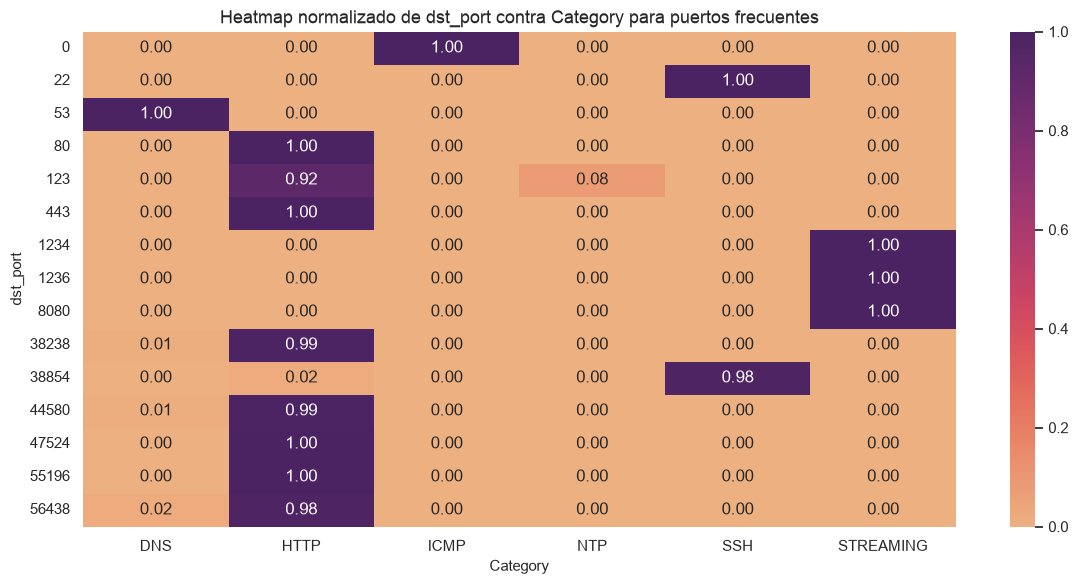

In [109]:
most_frequent_dst_ports = df_analysis_valid["dst_port"].value_counts().head(PORT_HEATMAP_TOP_N).index.tolist()
heatmap_frame = pd.crosstab(
    df_analysis_valid.loc[df_analysis_valid["dst_port"].isin(most_frequent_dst_ports), "dst_port"],
    df_analysis_valid.loc[df_analysis_valid["dst_port"].isin(most_frequent_dst_ports), TARGET_COLUMN],
    normalize="index",
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_frame, annot=True, fmt=".2f", cmap="flare")
plt.title("Heatmap normalizado de dst_port contra Category para puertos frecuentes")
plt.xlabel("Category")
plt.ylabel("dst_port")
finalize_figure("17_dst_port_heatmap")



## Seccion 6: Correlacion y asociacion

Para esta seccion, dado que tenemos variables numericas que tienen una posible relacion medible en una correlacion, y otras que no pueden ser tomadas directamente en estos analisis, se ha optado por la separacion en dos diferentes conceptos, tomando en cuenta la correlacion como una medida cuantificable de relacion entre las variables numericas del dataset, permitiendo evaluar cuales de estas variables muestran un incremento o decremento similar.

Para esta seccion de analisis de correlacion, se usa dos diferentes acercamientos. Especificamente se usa Pearson, que permite evaluar la correlacion entre las variables tomando en cuenta una relacion lineal entre las variables, y se usa ademas Spearman para identificar correlaciones entre variables aun cuando no existe una relacion lineal entre las variables.




In [110]:
#! Extraemos las columnas del dataset en general, y aplicamos para las features una transformacion a tipo numerico entero, mientras que
#! para el resto de columnas simplemente seleccionamos las columnas que no tienen un tipo no numerico
numeric_view = df.copy()
for feature in FEATURE_COLUMNS:
    numeric_view[feature] = pd.to_numeric(numeric_view[feature], errors="coerce")

numeric_columns_for_corr = numeric_view.select_dtypes(include=[np.number]).columns.tolist()
identifier_set = set(identifier_like_columns)
numeric_columns_for_corr = [column for column in numeric_columns_for_corr if column not in identifier_set]

### Exploracion visual de la correlacion de Pearson y Spearman aplicadas a las variables numericas del dataset

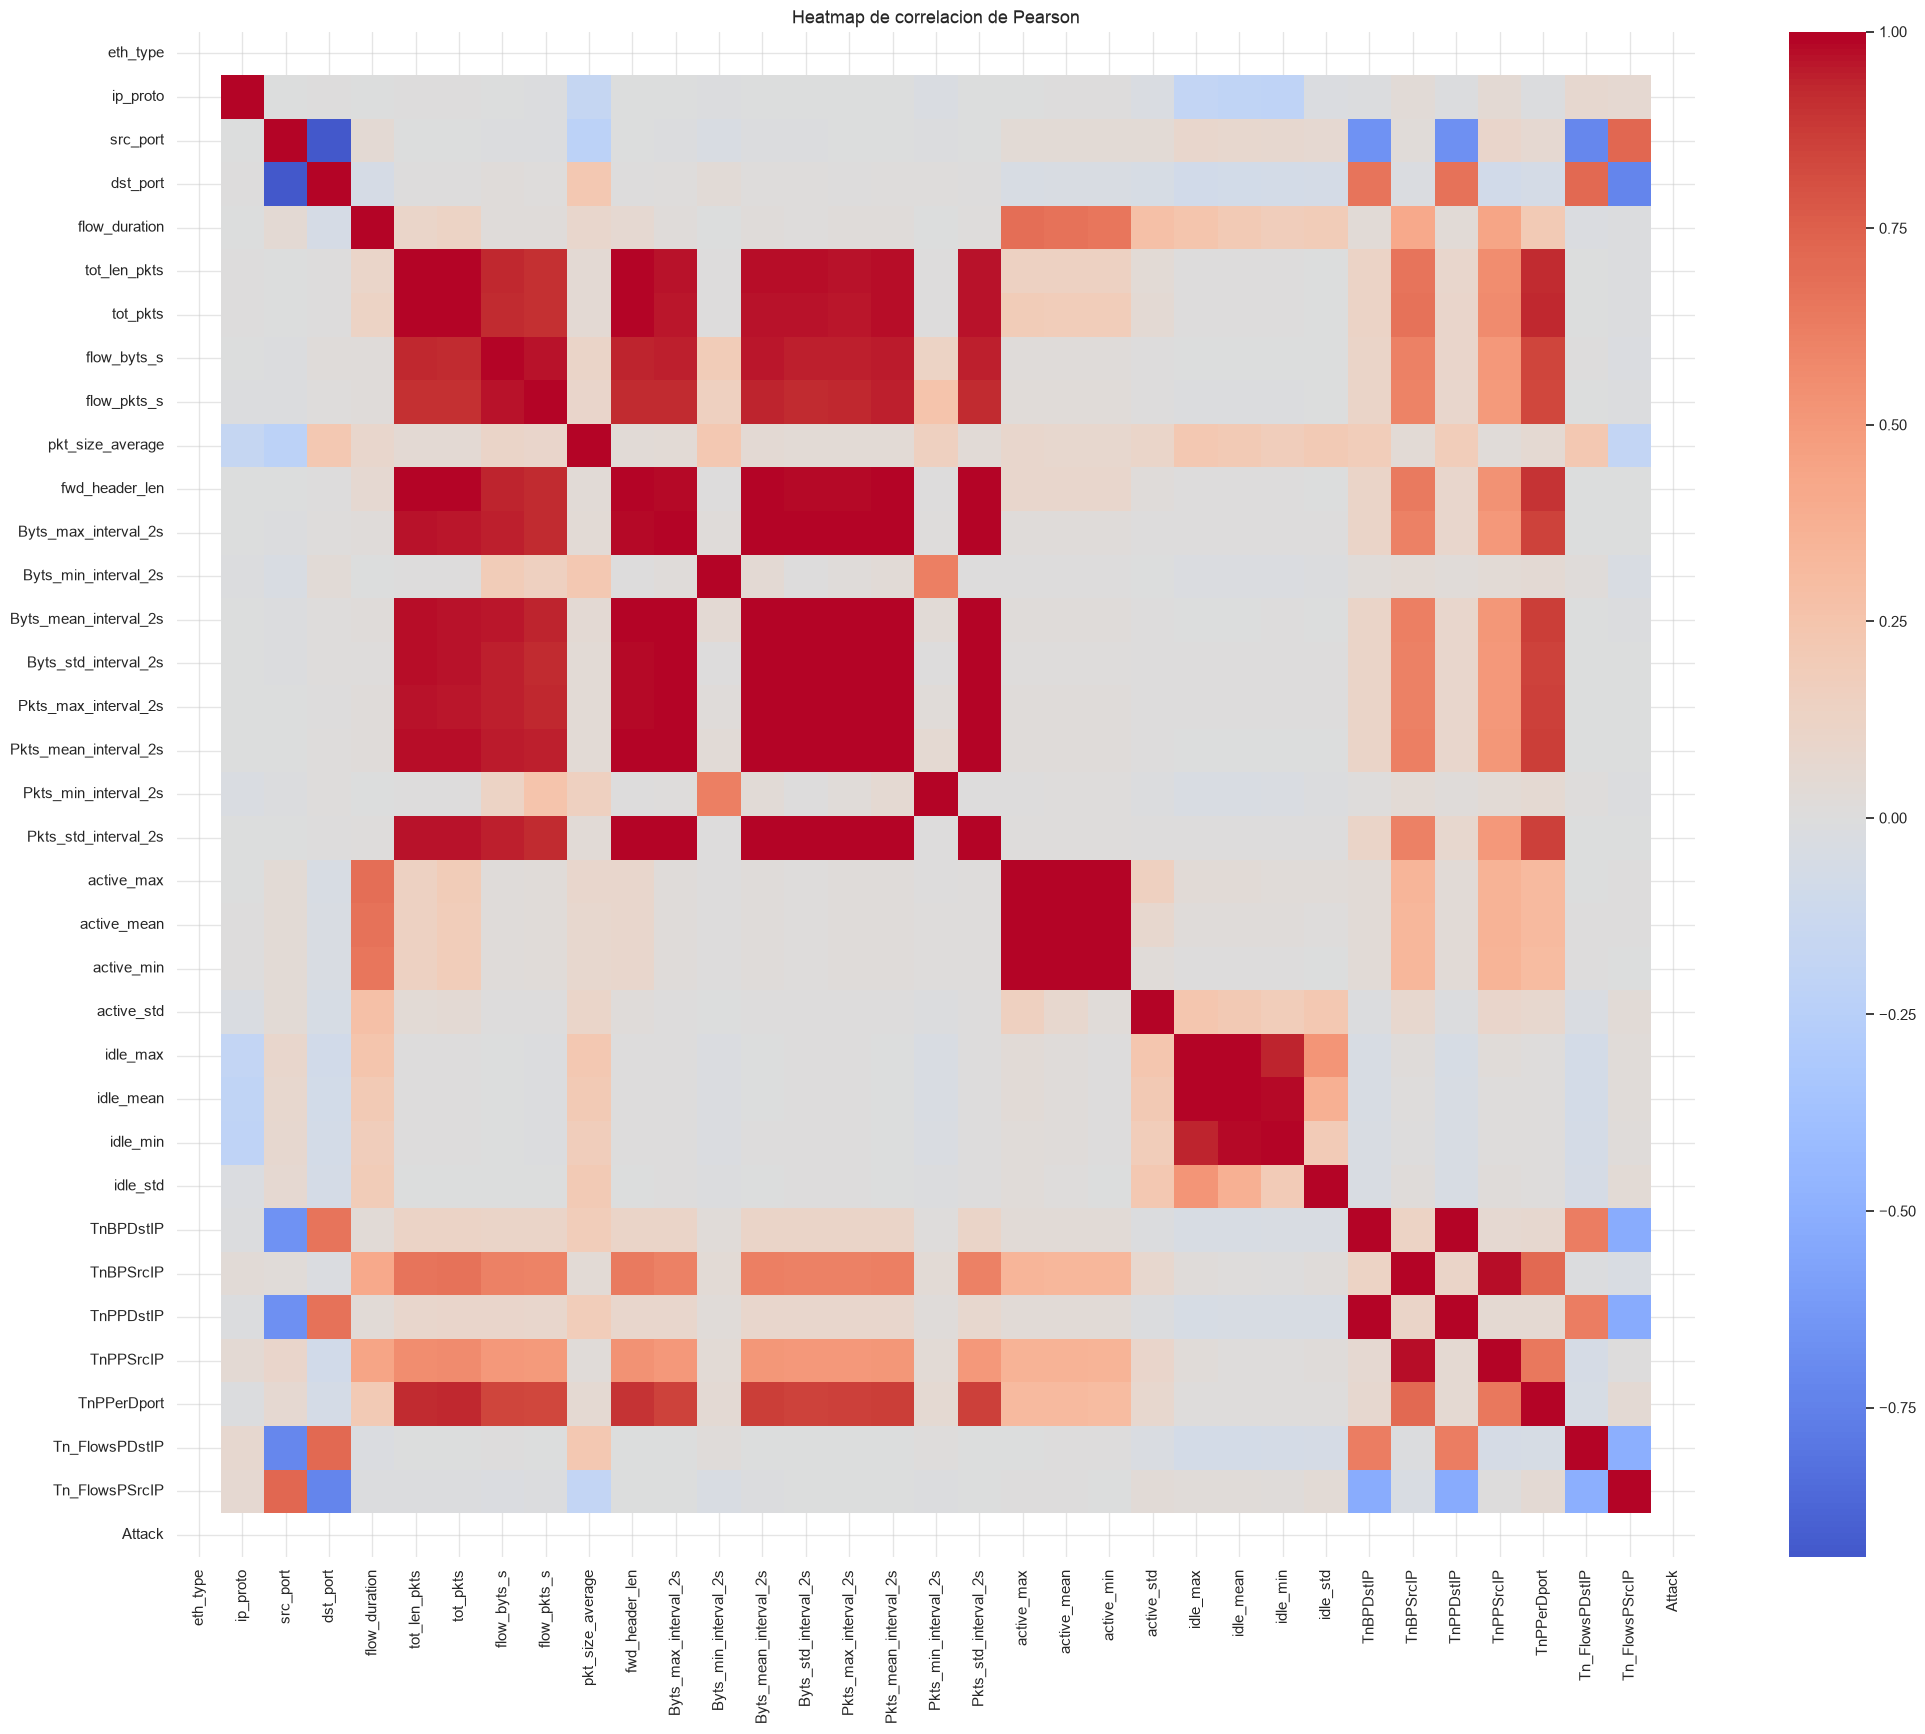

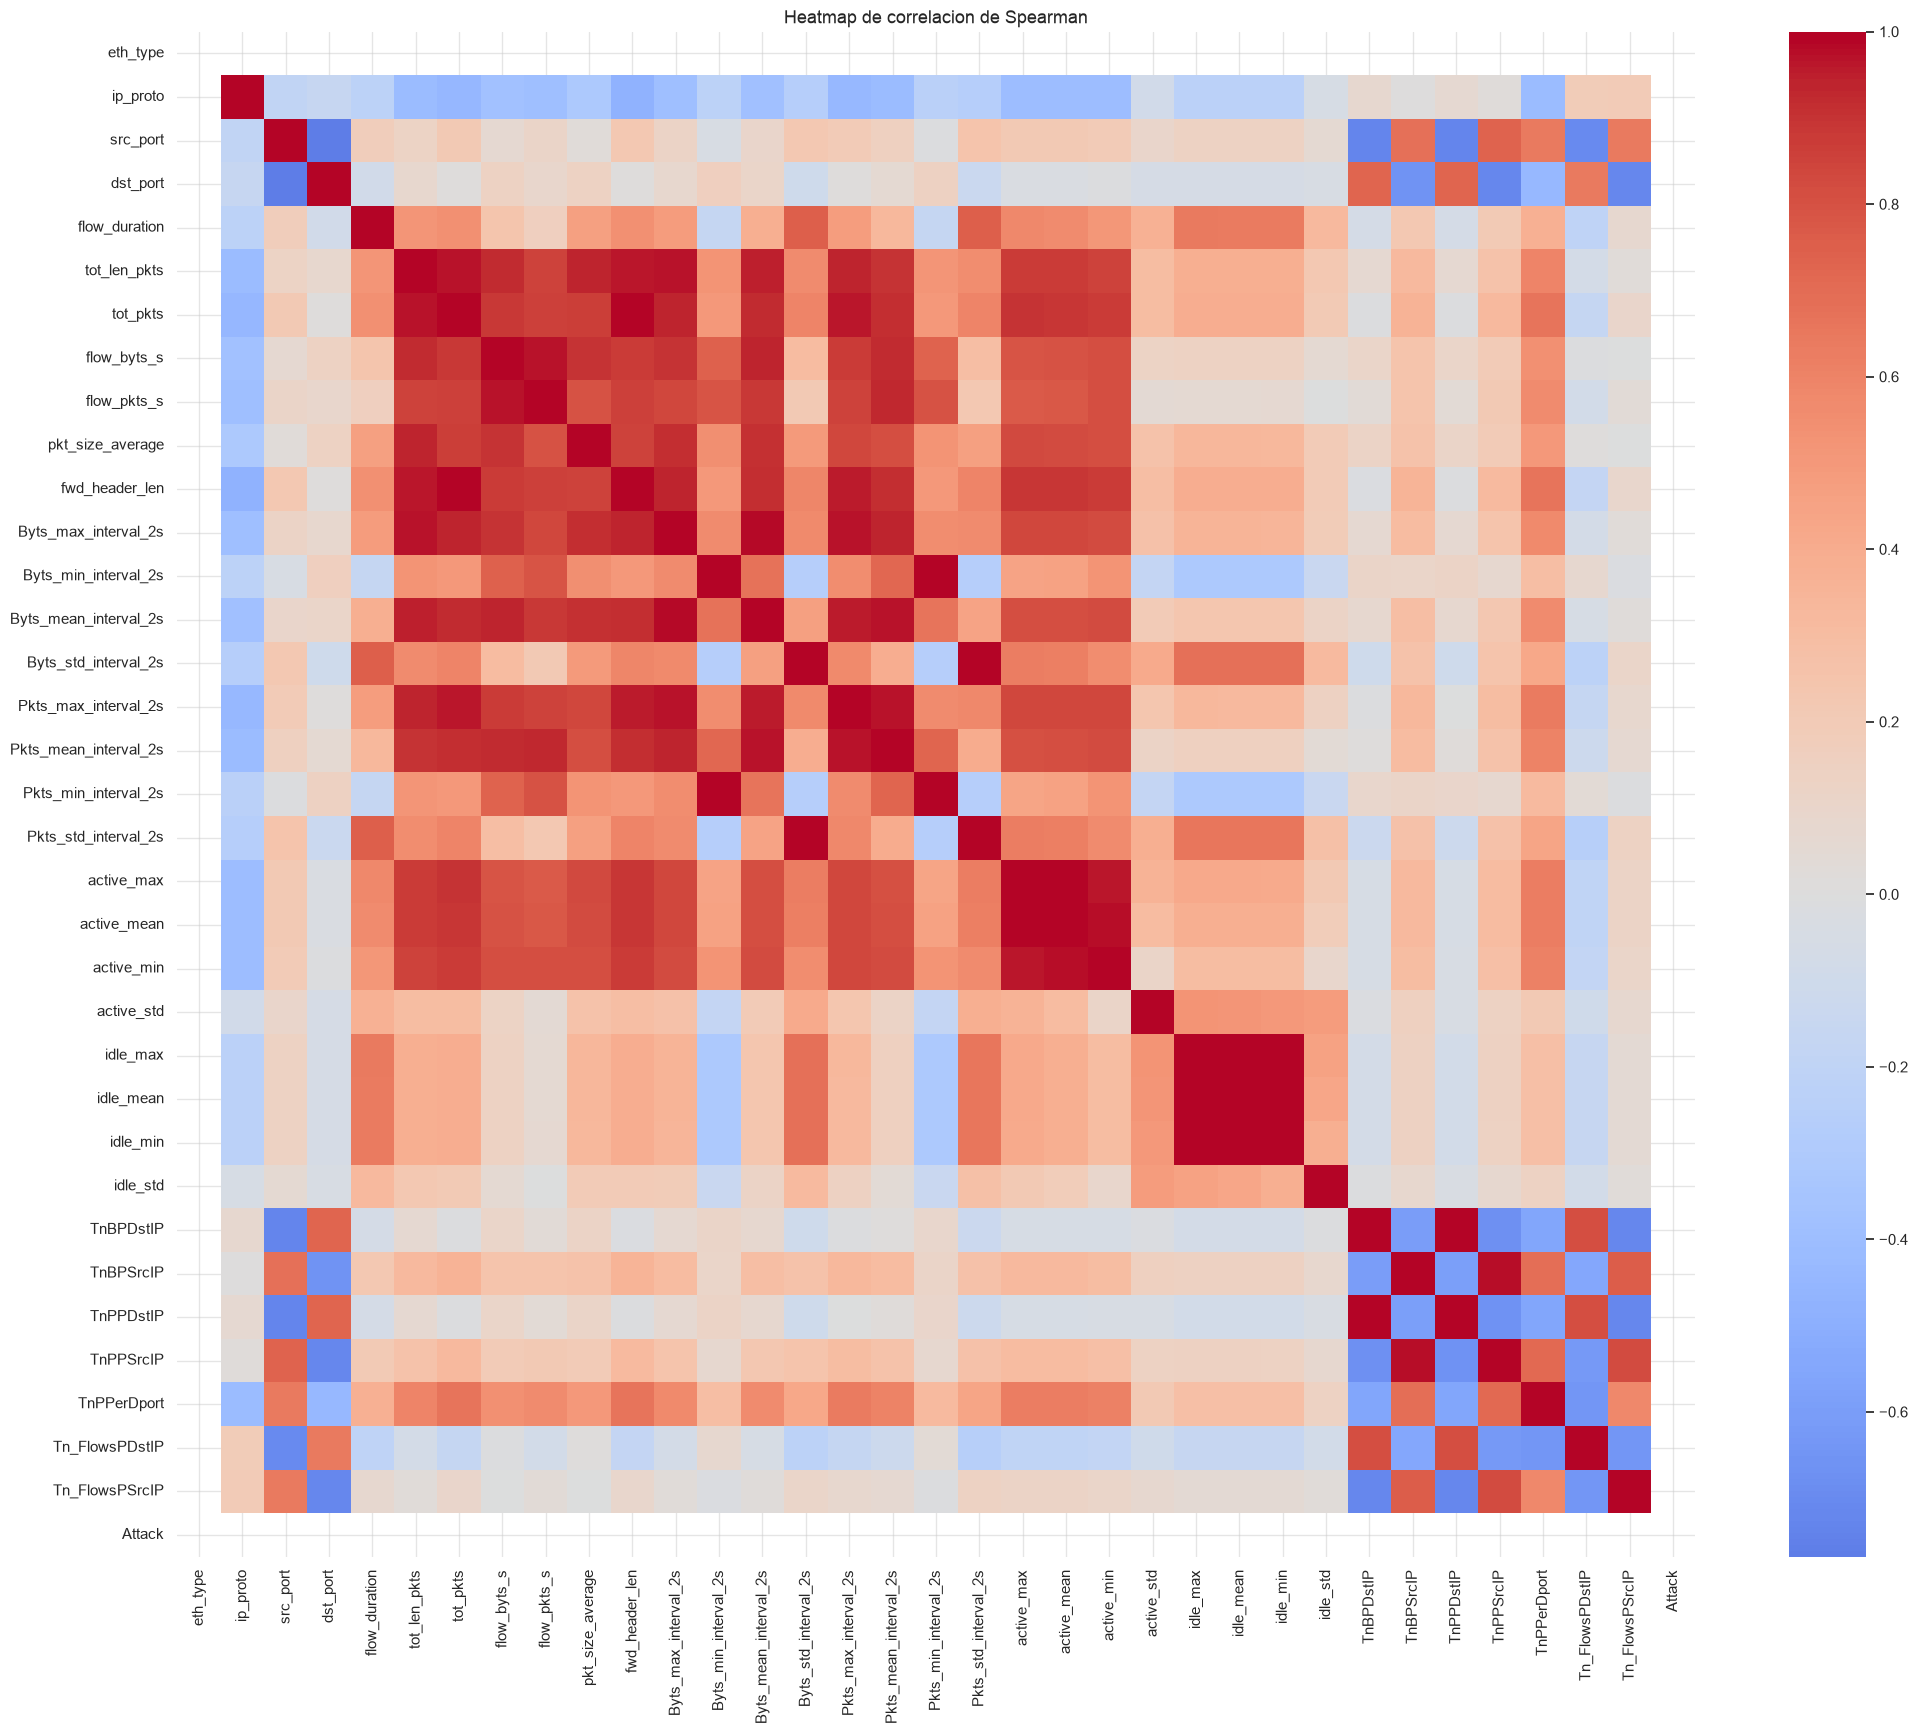

In [111]:
if numeric_columns_for_corr:
    pearson_corr = numeric_view[numeric_columns_for_corr].corr(method="pearson")
    spearman_corr = numeric_view[numeric_columns_for_corr].corr(method="spearman")

    plt.figure(figsize=(max(8, len(pearson_corr) * 0.6), max(6, len(pearson_corr) * 0.5)))
    sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
    plt.title("Heatmap de correlacion de Pearson")
    finalize_figure("21_corr_pearson")

    plt.figure(figsize=(max(8, len(spearman_corr) * 0.6), max(6, len(spearman_corr) * 0.5)))
    sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
    plt.title("Heatmap de correlacion de Spearman")
    finalize_figure("22_corr_spearman")


## Seccion 7: Limpieza final de los datos y exporte de datasets limpios



In [59]:
#! Definimos las columnas de salida del notebook, correspondientes a las features y el target solo
OUTPUT_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

#? Verificamos que todas las columnas existan en el dataframe
missing_columns = [
    column
    for column in OUTPUT_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Faltan columnas obligatorias: {missing_columns}"
    )

# Crea un nuevo DataFrame con las variables del modelo y la categoria objetivo.
df_clean = df[OUTPUT_COLUMNS].copy()
df_clean[TARGET_COLUMN] = normalize_category_series(
    df_clean[TARGET_COLUMN]
)
_, numeric_features, feature_details = feature_validity_report(df_clean)
invalid_feature_rows = pd.Series(False, index=df_clean.index)

for feature in FEATURE_COLUMNS:
    invalid_feature_rows |= feature_details[feature]["invalid_mask"]

if invalid_feature_rows.any():
    invalid_count = int(invalid_feature_rows.sum())

    raise ValueError(
        f"Se encontraron {invalid_count} filas con valores invalidos "
        "en las variables seleccionadas."
    )


for feature in FEATURE_COLUMNS:
    df_clean[feature] = numeric_features[feature].astype("Int64")

# Conserva el orden definido en FEATURE_COLUMNS y coloca el target al final.
df_clean = df_clean[OUTPUT_COLUMNS].reset_index(drop=True)

# Construye la ruta final de exportacion.
training_output_path = OUTPUT_DIR / TRAINING_OUTPUT_FILENAME

# Crea el directorio de salida cuando no exista.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Guarda el dataset reducido sin incluir el indice de Pandas.
df_clean.to_csv(
    training_output_path,
    index=False,
    encoding="utf-8",
)

# Muestra una vista rapida del resultado.
display(df_clean.head())

print(f"Dataset limpio guardado en: {training_output_path}")
print(f"Dimensiones finales: {df_clean.shape}")
print(f"Columnas finales: {df_clean.columns.tolist()}")
print(f"Tipos finales:\n{df_clean.dtypes}")

,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


Dataset limpio guardado en: ../../../res/data/processed/SDNFlow_Training_Sample_Dataset.csv
Dimensiones finales: (221564, 5)
Columnas finales: ['eth_type', 'ip_proto', 'src_port', 'dst_port', 'Category']
Tipos finales:
eth_type     Int64
ip_proto     Int64
src_port     Int64
dst_port     Int64
Category    string
dtype: object
